# Librerias

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob
import os
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
import statsmodels.formula.api as smf
from data_profiling import ProfileReport
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import TimeSeriesSplit
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [2]:
df_original = pd.read_csv("LLAN0095_total.csv")

In [3]:
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 949041 entries, 0 to 949040
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Date              949041 non-null  object 
 1   AMA               940452 non-null  float64
 2   AMV               940452 non-null  float64
 3   AVOA              940422 non-null  float64
 4   AVOV              940422 non-null  float64
 5   CT                940427 non-null  float64
 6   DeltaP            940372 non-null  float64
 7   Pd                940372 non-null  float64
 8   Pi                940372 non-null  float64
 9   PWF               0 non-null       float64
 10  RUN FREQ SETTING  366 non-null     float64
 11  RUN FREQ.         940417 non-null  float64
 12  RUN STATUS        947449 non-null  float64
 13  SD LAST REASON    416 non-null     float64
 14  Ti                940374 non-null  float64
 15  Tm                940373 non-null  float64
 16  VX                94

## Calculo caudal

In [4]:
df = df_original[['Date','AMA', 'AMV', 'AVOA', 'AVOV','RUN FREQ.','Pd', 'Pi','Ti','Tm','VX']]

In [ ]:
df['Caudal']= 58847 * sqrt (3) * df['AVOV'] * df ['AVOA']

,Date,AMA,AMV,AVOA,AVOV,RUN FREQ.,Pd,Ti,Tm,VX
0,2024-01-01 00:00:30,24.283,1718.4,130.4,320.0,42.0,2501.1,141.8,188.6,0.326
1,2024-01-01 00:01:30,24.320,1718.4,130.6,320.0,42.0,2499.8,141.8,188.6,0.298
2,2024-01-01 00:02:30,24.283,1718.4,130.4,320.0,42.0,2499.8,141.8,188.6,0.267
3,2024-01-01 00:03:30,24.283,1718.4,130.4,320.0,42.0,2498.0,140.0,188.6,0.310
4,2024-01-01 00:04:30,24.320,1718.4,130.6,320.0,42.0,2496.3,140.0,188.6,0.272
...,...,...,...,...,...,...,...,...,...,...
949036,2025-12-31 23:55:30,25.320,1843.7,130.4,358.0,45.0,2498.6,140.4,200.3,0.197
949037,2025-12-31 23:56:30,25.359,1843.7,130.6,358.0,45.0,2498.6,140.4,200.3,0.232
949038,2025-12-31 23:57:31,25.379,1843.7,130.7,358.0,45.0,2498.8,140.4,200.5,0.137
949039,2025-12-31 23:58:30,25.359,1843.7,130.6,358.0,45.0,2499.0,140.4,200.3,0.133


In [6]:
df.describe()

,AMA,AMV,AVOA,AVOV,RUN FREQ.,Pd,Ti,Tm,VX
count,940452.000000,940452.000000,940422.000000,940422.000000,940417.000000,940372.000000,940374.000000,940373.000000,940427.000000
mean,21.994717,1844.749892,113.765095,357.176976,45.059013,2474.189159,142.125829,176.669568,0.216327
std,3.692818,203.426049,19.120454,39.848705,4.896897,180.461029,9.297422,21.842315,0.075162
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.243000,1843.700000,99.100000,358.000000,45.000000,2486.400000,140.500000,156.900000,0.167000
50%,19.573000,1843.700000,100.800000,358.000000,45.000000,2491.700000,141.200000,161.700000,0.205000
75%,25.165000,1843.700000,130.000000,358.000000,45.000000,2501.100000,143.100000,200.300000,0.255000
max,77.132000,2472.000000,414.200000,480.000000,60.000000,2810.500000,249.000000,274.600000,1.233000


In [7]:
df = df.copy()
# convertir fecha
df['Date'] = pd.to_datetime(df['Date'])
# ordenar cronológicamente
df = df.sort_values('Date')
# colocar fecha como índice
df = df.set_index('Date')

FILTRO DE FECHAS - Gráficas de Pd, Ti, Tm, VX


Button(button_style='info', description='Actualizar Gráfica', style=ButtonStyle(), tooltip='Click para actuali…

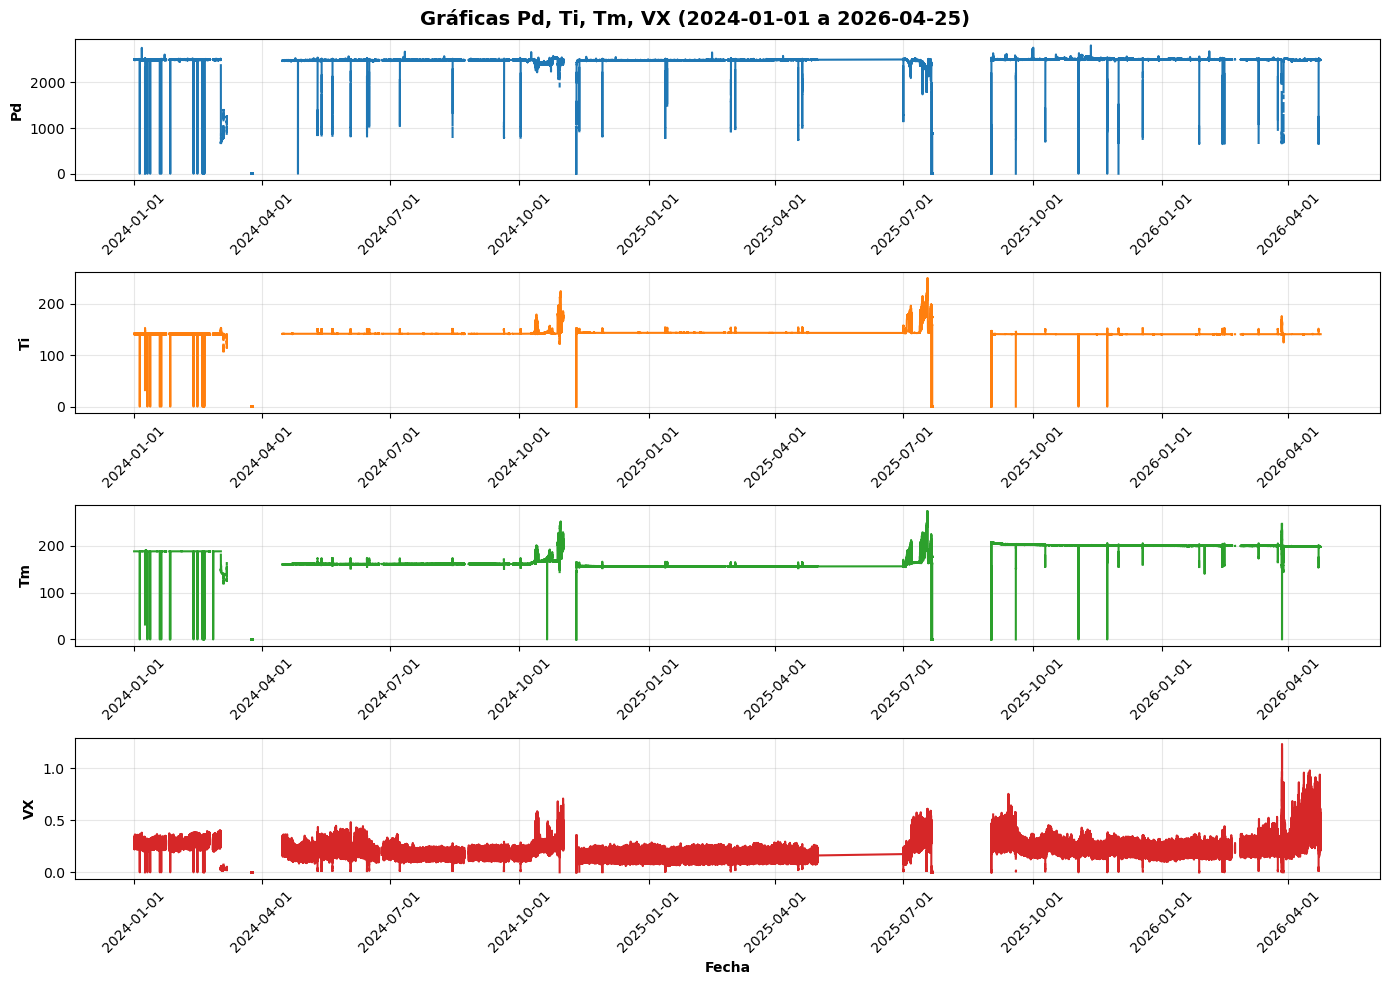

In [8]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.dates as mdates

# Obtener rango de fechas disponibles
fecha_min = df.index.min()
fecha_max = df.index.max()

# Crear widgets para filtro de fechas
date_picker_start = widgets.DatePicker(
    value=fecha_min.date(),
    description='Desde:',
    style={'description_width': '80px'}
)

date_picker_end = widgets.DatePicker(
    value=fecha_max.date(),
    description='Hasta:',
    style={'description_width': '80px'}
)

# Función para actualizar la gráfica
def plot_with_filter(start_date, end_date):
    # Filtrar datos por rango de fechas
    mask = (df.index.date >= start_date) & (df.index.date <= end_date)
    df_filtered = df[mask]
    
    if len(df_filtered) == 0:
        print("No hay datos en el rango de fechas seleccionado")
        return
    
    # Crear figura con 4 subplots
    fig, axes = plt.subplots(4, 1, figsize=(14, 10))
    fig.suptitle(f'Gráficas Pd, Ti, Tm, VX ({start_date} a {end_date})', fontsize=14, fontweight='bold')
    
    # Pd
    axes[0].plot(df_filtered.index, df_filtered['Pd'], linewidth=1.5, color='#1f77b4')
    axes[0].set_ylabel('Pd', fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    
    # Ti
    axes[1].plot(df_filtered.index, df_filtered['Ti'], linewidth=1.5, color='#ff7f0e')
    axes[1].set_ylabel('Ti', fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    
    # Tm
    axes[2].plot(df_filtered.index, df_filtered['Tm'], linewidth=1.5, color='#2ca02c')
    axes[2].set_ylabel('Tm', fontweight='bold')
    axes[2].grid(True, alpha=0.3)
    axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    
    # VX
    axes[3].plot(df_filtered.index, df_filtered['VX'], linewidth=1.5, color='#d62728')
    axes[3].set_ylabel('VX', fontweight='bold')
    axes[3].set_xlabel('Fecha', fontweight='bold')
    axes[3].grid(True, alpha=0.3)
    axes[3].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    
    # Rotar etiquetas de fecha
    for ax in axes:
        ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

# Crear botón para actualizar
button_update = widgets.Button(
    description='Actualizar Gráfica',
    button_style='info',
    tooltip='Click para actualizar la gráfica'
)

# Manejador del botón
def on_button_click(b):
    plot_with_filter(date_picker_start.value, date_picker_end.value)

button_update.on_click(on_button_click)

# Mostrar controles
print("FILTRO DE FECHAS - Gráficas de Pd, Ti, Tm, VX")
print("=" * 50)
display(widgets.HBox([date_picker_start, date_picker_end]))
display(button_update)

# Mostrar gráfica inicial con todos los datos
plot_with_filter(fecha_min.date(), fecha_max.date())

# Machine learning

In [9]:
df = df.copy()

df['AMA_lag_1']  = df['AMA'].shift(1)
df['AMA_lag_2']  = df['AMA'].shift(2)
df['AMA_lag_5']  = df['AMA'].shift(5)
df['AMA_lag_15'] = df['AMA'].shift(15)
df['AMA_lag_30'] = df['AMA'].shift(30)
df['AMA_mean_30'] = df['AMA'].rolling(30).mean()
df['AMA_std_30'] = df['AMA'].rolling(30).std()

df['AVOV_lag_1']  = df['AVOV'].shift(1)
df['AVOV_lag_2']  = df['AVOV'].shift(2)
df['AVOV_lag_5']  = df['AVOV'].shift(5)
df['AVOV_lag_15'] = df['AVOV'].shift(15)
df['AVOV_lag_30'] = df['AVOV'].shift(30)
df['AVOV_mean_30'] = df['AVOV'].rolling(30).mean()
df['AVOV_std_30'] = df['AVOV'].rolling(30).std()

df['Ti_lag_31']  = df['Ti'].shift(31)
df['Ti_lag_32']  = df['Ti'].shift(32)
df['Ti_lag_35']  = df['Ti'].shift(35)
df['Ti_lag_45'] = df['Ti'].shift(45)
df['Ti_lag_60'] = df['Ti'].shift(60)
df['Ti_mean_31_60'] = df['Ti'].shift(30).rolling(30).mean()
df['Ti_std_31_60'] = df['Ti'].shift(30).rolling(30).std()

df['Tm_lag_31']  = df['Tm'].shift(31)
df['Tm_lag_32']  = df['Tm'].shift(32)
df['Tm_lag_35']  = df['Tm'].shift(35)
df['Tm_lag_45'] = df['Tm'].shift(45)
df['Tm_lag_60'] = df['Tm'].shift(60)
df['Tm_mean_31_60'] = df['Tm'].shift(30).rolling(30).mean()
df['Tm_std_31_60'] = df['Tm'].shift(30).rolling(30).std()

df['VX_lag_31']  = df['VX'].shift(31)
df['VX_lag_32']  = df['VX'].shift(32)
df['VX_lag_35']  = df['VX'].shift(35)
df['VX_lag_45'] = df['VX'].shift(45)
df['VX_lag_60'] = df['VX'].shift(60)
df['VX_mean_31_60'] = df['VX'].shift(30).rolling(30).mean()
df['VX_std_31_60'] = df['VX'].shift(30).rolling(30).std()

df.dropna(inplace=True)

In [10]:
df

,AMA,AMV,AVOA,AVOV,RUN FREQ.,Pd,Ti,Tm,VX,AMA_lag_1,...,Tm_lag_60,Tm_mean_31_60,Tm_std_31_60,VX_lag_31,VX_lag_32,VX_lag_35,VX_lag_45,VX_lag_60,VX_mean_31_60,VX_std_31_60
Date,,,,,,,,,,,,,,,,,,,,,
2024-01-01 01:00:30,24.283,1718.4,130.4,320.0,42.0,2501.1,141.8,188.6,0.245,24.264,...,188.6,188.600000,0.000000,0.276,0.301,0.289,0.256,0.326,0.278033,0.023532
2024-01-01 01:01:34,24.283,1718.4,130.4,320.0,42.0,2502.4,141.8,188.6,0.317,24.283,...,188.6,188.600000,0.000000,0.277,0.276,0.303,0.268,0.298,0.277233,0.023236
2024-01-01 01:02:30,24.264,1718.4,130.3,320.0,42.0,2502.4,141.8,188.6,0.317,24.283,...,188.6,188.600000,0.000000,0.274,0.277,0.266,0.313,0.267,0.278267,0.023453
2024-01-01 01:03:34,24.283,1718.4,130.4,320.0,42.0,2497.4,140.0,188.6,0.312,24.264,...,188.6,188.600000,0.000000,0.298,0.274,0.301,0.242,0.310,0.277900,0.023022
2024-01-01 01:04:30,24.302,1718.4,130.5,320.0,42.0,2497.4,140.0,188.6,0.312,24.283,...,188.6,188.600000,0.000000,0.299,0.298,0.276,0.259,0.272,0.277867,0.023032
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-23 21:38:30,24.680,1843.7,127.1,358.0,45.0,2494.8,140.4,198.2,0.293,24.680,...,198.2,198.186667,0.077608,0.352,0.462,0.477,0.329,0.364,0.357033,0.065356
2026-04-23 21:39:32,24.738,1843.7,127.4,358.0,45.0,2494.7,140.5,198.4,0.275,24.680,...,198.2,198.183333,0.079148,0.343,0.352,0.293,0.286,0.282,0.357300,0.065055
2026-04-23 21:40:30,24.757,1843.7,127.5,358.0,45.0,2494.0,140.5,198.2,0.336,24.738,...,198.2,198.183333,0.079148,0.290,0.343,0.340,0.427,0.348,0.359900,0.066219


In [11]:
def evaluar(y_true, y_pred, nombre):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"{nombre} -> RMSE: {rmse:.3f} | R2: {r2:.3f}")

# Pd 

In [12]:
features = [
    # variables originales
    'AMA',
    'AMV',
    'AVOA',
    'AVOV',
    'RUN FREQ.',
    # AMA temporal
    'AMA_lag_1',
    'AMA_lag_2',
    'AMA_lag_5',
    'AMA_lag_15',
    'AMA_lag_30',
    'AMA_mean_30',
    'AMA_std_30',
    # AVOV temporal
    'AVOV_lag_1',
    'AVOV_lag_2',
    'AVOV_lag_5',
    'AVOV_lag_15',
    'AVOV_lag_30',
    'AVOV_mean_30',
    'AVOV_std_30'
]

target = 'Pd'

df_model = df[features + [target]].copy()
X = df_model[features]
y = df_model[target]

In [13]:
# Garantizar que los datos estén ordenados por fecha
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)
print("="*60)

print("TRAIN")

print(f"Inicio : {X_train.index.min()}")
print(f"Fin    : {X_train.index.max()}")
print(f"Datos  : {len(X_train):,}")

print()

print("TEST")

print(f"Inicio : {X_test.index.min()}")
print(f"Fin    : {X_test.index.max()}")
print(f"Datos  : {len(X_test):,}")

print("="*60)

TRAIN
Inicio : 2024-01-01 01:00:30
Fin    : 2025-12-07 10:06:30
Datos  : 730,308

TEST
Inicio : 2025-12-07 10:07:34
Fin    : 2026-04-23 21:42:30
Datos  : 182,578


### Regresion lineal

In [14]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

### Random Forest

In [15]:
rf = RandomForestRegressor(
    n_estimators=200,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features='sqrt',
    max_depth=20,
    random_state=42,
    n_jobs=-1
    )
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

IMPORTANCIA DE CARACTERÍSTICAS - RANDOM FOREST
     Feature  Importance
  AMA_std_30    0.120686
 AMA_mean_30    0.083224
   AMA_lag_2    0.072079
         AMA    0.066137
AVOV_mean_30    0.062119
  AMA_lag_30    0.059765
   AMA_lag_5    0.058080
 AVOV_lag_30    0.051509
   AMA_lag_1    0.051215
  AMA_lag_15    0.049664
        AVOV    0.049086
  AVOV_lag_1    0.047651
 AVOV_lag_15    0.044219
  AVOV_lag_5    0.037630
        AVOA    0.037331
         AMV    0.032686
   RUN FREQ.    0.029679
 AVOV_std_30    0.024586
  AVOV_lag_2    0.022653


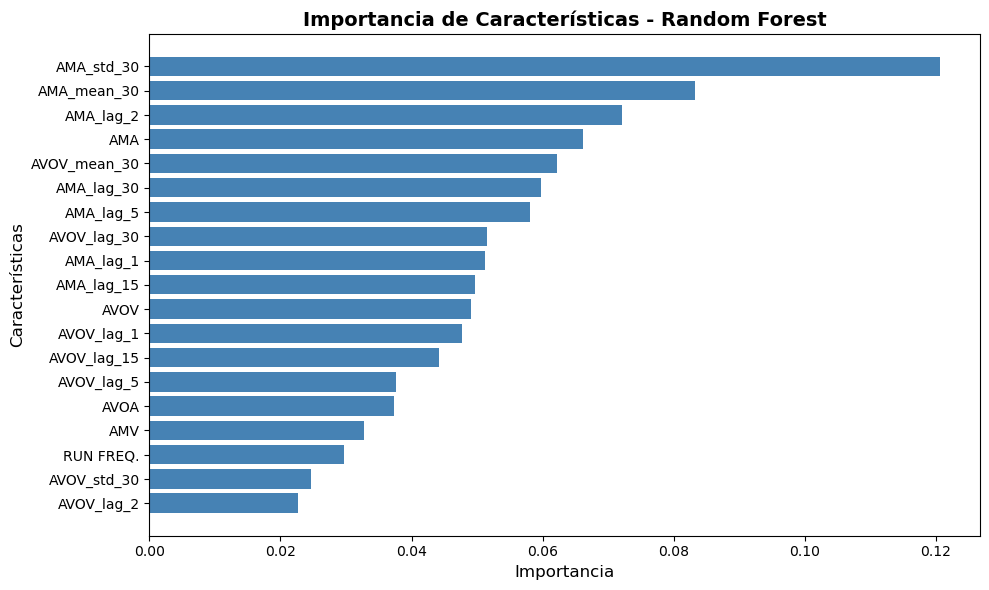


PARTICIPACIÓN PORCENTUAL:
     Feature  Participacion %
  AMA_std_30            12.07
 AMA_mean_30             8.32
   AMA_lag_2             7.21
         AMA             6.61
AVOV_mean_30             6.21
  AMA_lag_30             5.98
   AMA_lag_5             5.81
 AVOV_lag_30             5.15
   AMA_lag_1             5.12
  AMA_lag_15             4.97
        AVOV             4.91
  AVOV_lag_1             4.77
 AVOV_lag_15             4.42
  AVOV_lag_5             3.76
        AVOA             3.73
         AMV             3.27
   RUN FREQ.             2.97
 AVOV_std_30             2.46
  AVOV_lag_2             2.27


In [16]:
# Importancia de las características en el modelo Random Forest
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("IMPORTANCIA DE CARACTERÍSTICAS - RANDOM FOREST")
print("=" * 50)
print(feature_importance.to_string(index=False))
print("=" * 50)

# Gráfico de importancia
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
plt.xlabel('Importancia', fontsize=12)
plt.ylabel('Características', fontsize=12)
plt.title('Importancia de Características - Random Forest', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Participación porcentual
feature_importance['Participacion %'] = (feature_importance['Importance'] / feature_importance['Importance'].sum() * 100).round(2)
print("\nPARTICIPACIÓN PORCENTUAL:")
print(feature_importance[['Feature', 'Participacion %']].to_string(index=False))

### Gradient Boosting

In [17]:
gbr = GradientBoostingRegressor(
    subsample=0.8,
    n_estimators=200,
    min_samples_split=10,
    min_samples_leaf=1,
    max_features=None,
    max_depth=3,
    learning_rate=0.01,
    random_state=42
    )
gbr.fit(X_train, y_train)

y_pred_gbr = gbr.predict(X_test)

### XGBRegresorr

In [18]:
# Modelo
xgb = XGBRegressor(
    subsample=0.8,
    reg_lambda=2,
    reg_alpha=0.1,
    n_estimators=200,
    min_child_weight=1,
    max_depth=3,
    learning_rate=0.01,
    gamma=0.3,
    colsample_bytree=0.7,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

# Entrenar
xgb.fit(X_train, y_train)

# Predicción
y_pred_xgb = xgb.predict(X_test)

### LightGBM

In [19]:
# Modelo
lgbm = LGBMRegressor(
    boosting_type='gbdt',
    n_estimators=200,
    learning_rate=0.01,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.7,
    reg_alpha=0.1,
    reg_lambda=2,
    random_state=42,
    n_jobs=-1
)

# Entrenar
lgbm.fit(X_train, y_train)
# Predicción
y_pred_lgbm = lgbm.predict(X_test)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,007863 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3126
[LightGBM] [Info] Number of data points in the train set: 730308, number of used features: 19
[LightGBM] [Info] Start training from score 2479,130163
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

### Catboost

In [20]:
# Modelo
cat = CatBoostRegressor(
    iterations=200,
    learning_rate=0.01,
    depth=3,
    subsample=0.8,
    l2_leaf_reg=2,
    random_seed=42,
    loss_function='RMSE',
    verbose=0
)

# Entrenar
cat.fit(X_train, y_train)
# Predicción
y_pred_cat = cat.predict(X_test)

### Evaluacion

In [21]:


evaluar(y_test, y_pred_lr,  "Linear Regression")
evaluar(y_test, y_pred_rf,  "Random Forest")
evaluar(y_test, y_pred_gbr, "Gradient Boosting")
evaluar(y_test, y_pred_xgb, "XGBoost")
evaluar(y_test, y_pred_lgbm, "LightGBM")
evaluar(y_test, y_pred_cat, "CatBoost")

Linear Regression -> RMSE: 68.535 | R2: 0.813
Random Forest -> RMSE: 69.032 | R2: 0.810
Gradient Boosting -> RMSE: 21.385 | R2: 0.982
XGBoost -> RMSE: 22.354 | R2: 0.980
LightGBM -> RMSE: 21.026 | R2: 0.982
CatBoost -> RMSE: 24.390 | R2: 0.976


In [22]:
# Crear tabla de evaluación
resultados = []

modelos = {
    "Linear Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gbr,
    "XGBoost": y_pred_xgb,
    "LightGBM": y_pred_lgbm,
    "CatBoost": y_pred_cat
}

for nombre, predicciones in modelos.items():
    mse = mean_squared_error(y_test, predicciones)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, predicciones)
    r2 = r2_score(y_test, predicciones)
    
    resultados.append({
        "Modelo": nombre,
        "RMSE": round(rmse, 4),
        "MAE": round(mae, 4),
        "R² Score": round(r2, 4),
        "MSE": round(mse, 4)
    })

tabla_evaluacion = pd.DataFrame(resultados)
tabla_evaluacion

,Modelo,RMSE,MAE,R² Score,MSE
0,Linear Regression,68.5347,17.7877,0.8128,4697.0031
1,Random Forest,69.0321,61.9258,0.8100,4765.4269
2,Gradient Boosting,21.3852,10.0286,0.9818,457.3258
3,XGBoost,22.3536,9.5318,0.9801,499.6849
4,LightGBM,21.0264,9.9440,0.9824,442.1115
5,CatBoost,24.3899,13.0611,0.9763,594.8677


### Grafica

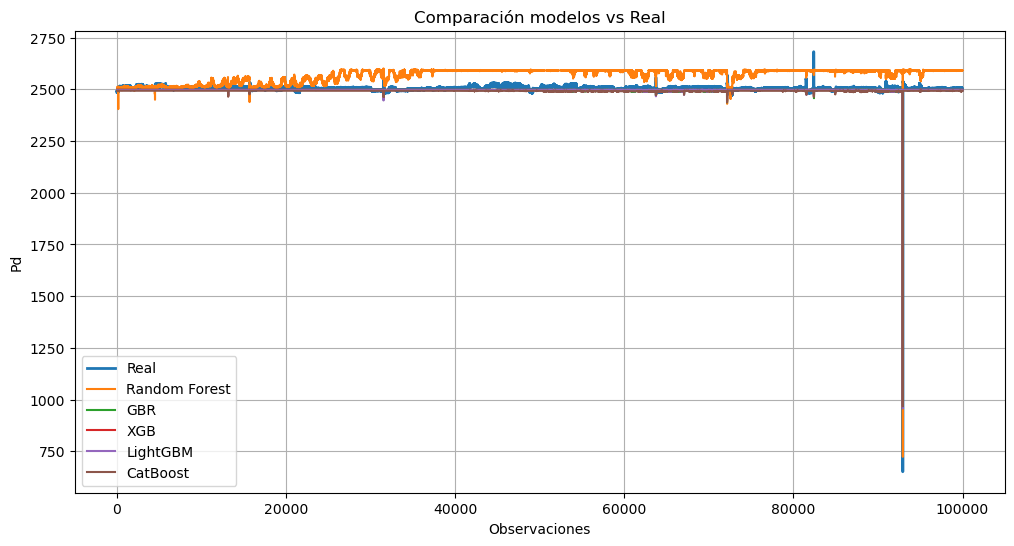

In [28]:
plt.figure(figsize=(12,6))

window_max=100000

plt.plot(y_test.values[:window_max], label='Real', linewidth=2)
#plt.plot(y_pred_lr[:window_max], label='Linear')
plt.plot(y_pred_rf[:window_max], label='Random Forest')
plt.plot(y_pred_gbr[:window_max], label='GBR')
plt.plot(y_pred_xgb[:window_max], label='XGB')
plt.plot(y_pred_lgbm[:window_max], label='LightGBM')
plt.plot(y_pred_cat[:window_max], label='CatBoost')

plt.legend()
plt.title('Comparación modelos vs Real')
plt.xlabel('Observaciones')
plt.ylabel('Pd')
plt.grid(True)

plt.show()

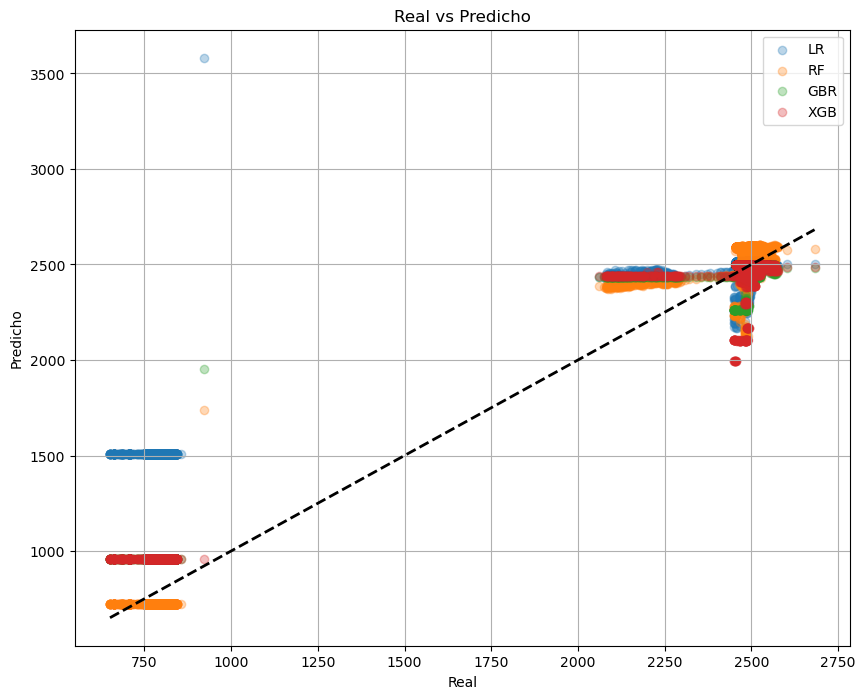

In [24]:
plt.figure(figsize=(10,8))

plt.scatter(y_test, y_pred_lr, alpha=0.3, label='LR')
plt.scatter(y_test, y_pred_rf, alpha=0.3, label='RF')
#plt.scatter(y_test, y_pred_svr, alpha=0.3, label='SVR')
plt.scatter(y_test, y_pred_gbr, alpha=0.3, label='GBR')
plt.scatter(y_test, y_pred_xgb, alpha=0.3, label='XGB')

# Línea ideal
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'k--', linewidth=2)

plt.xlabel('Real')
plt.ylabel('Predicho')
plt.title('Real vs Predicho')
plt.legend()
plt.grid(True)

plt.show()

In [25]:
print("Fecha inicial:", y_test.index.min())
print("Fecha final:", y_test.index.max())

Fecha inicial: 2025-12-07 10:07:34
Fecha final: 2026-04-23 21:42:30


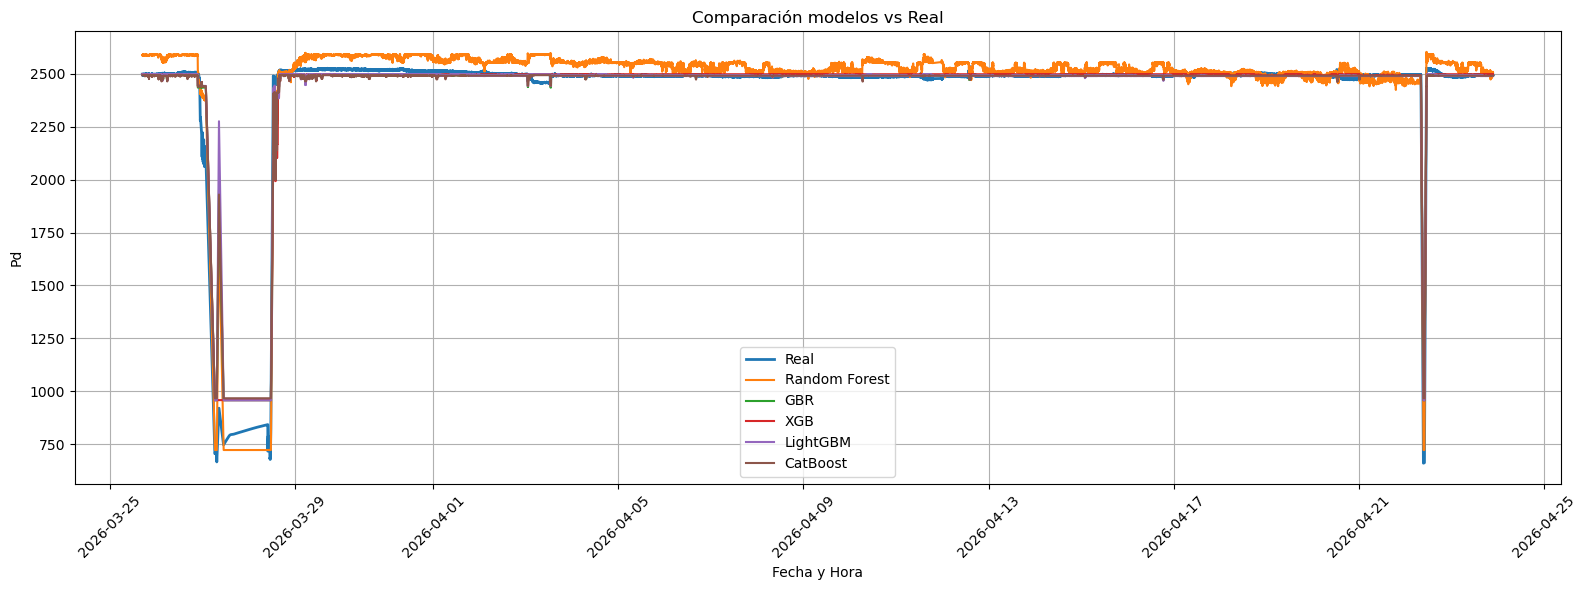

In [29]:
inicio = '2026-03-25 17:00:00'
fin    = '2026-04-30 20:00:00'

mask = (y_test.index >= inicio) & (y_test.index <= fin)

plt.figure(figsize=(16,6))

plt.plot(y_test.index[mask], y_test[mask], label='Real', linewidth=2)
plt.plot(y_test.index[mask], y_pred_rf[mask], label='Random Forest')
plt.plot(y_test.index[mask], y_pred_gbr[mask], label='GBR')
plt.plot(y_test.index[mask], y_pred_xgb[mask], label='XGB')
# plt.plot(y_test.index[mask], y_pred_lr[mask], label='Linear')
plt.plot(y_test.index[mask], y_pred_lgbm[mask], label='LightGBM')
plt.plot(y_test.index[mask], y_pred_cat[mask], label='CatBoost')




plt.legend()
plt.title('Comparación modelos vs Real')
plt.xlabel('Fecha y Hora')
plt.ylabel('Pd')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Ti

In [45]:
features = [
    # variables originales
    'AMA',
    'AMV',
    'AVOA',
    'AVOV',
    'RUN FREQ.',
    # AMA temporal
    'AMA_lag_1',
    'AMA_lag_2',
    'AMA_lag_5',
    'AMA_lag_15',
    'AMA_lag_30',
    'AMA_mean_30',
    'AMA_std_30',
    # AVOV temporal
    'AVOV_lag_1',
    'AVOV_lag_2',
    'AVOV_lag_5',
    'AVOV_lag_15',
    'AVOV_lag_30',
    'AVOV_mean_30',
    'AVOV_std_30',
    # Ti temporal
    'Ti_lag_31',
    'Ti_lag_32',
    'Ti_lag_35',
    'Ti_lag_45',
    'Ti_lag_60',
    'Ti_mean_31_60',
    'Ti_std_31_60'
]

target = 'Ti'

df_model = df[features + [target]].copy()
X = df_model[features]
y = df_model[target]

In [46]:
# Garantizar que los datos estén ordenados por fecha
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)
print("="*60)

print("TRAIN")

print(f"Inicio : {X_train.index.min()}")
print(f"Fin    : {X_train.index.max()}")
print(f"Datos  : {len(X_train):,}")

print()

print("TEST")

print(f"Inicio : {X_test.index.min()}")
print(f"Fin    : {X_test.index.max()}")
print(f"Datos  : {len(X_test):,}")

print("="*60)

TRAIN
Inicio : 2024-01-01 01:00:30
Fin    : 2025-12-07 10:06:30
Datos  : 730,308

TEST
Inicio : 2025-12-07 10:07:34
Fin    : 2026-04-23 21:42:30
Datos  : 182,578


### Regresion lineal

In [47]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

### Random Forest

In [48]:
rf = RandomForestRegressor(
    n_estimators=200,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features='sqrt',
    max_depth=10,
    random_state=42,
    n_jobs=-1
    )
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

IMPORTANCIA DE CARACTERÍSTICAS - RANDOM FOREST
      Feature  Importance
    Ti_lag_31    0.227899
    Ti_lag_32    0.188742
Ti_mean_31_60    0.131339
    Ti_lag_35    0.119115
    Ti_lag_45    0.112979
    Ti_lag_60    0.086314
 Ti_std_31_60    0.026159
   AVOV_lag_5    0.010719
  AVOV_lag_30    0.010683
  AMA_mean_30    0.010036
   AMA_std_30    0.009747
 AVOV_mean_30    0.009295
  AVOV_lag_15    0.006455
   AVOV_lag_1    0.005964
   AVOV_lag_2    0.004865
   AMA_lag_30    0.004653
   AMA_lag_15    0.004447
    AMA_lag_5    0.004325
    AMA_lag_2    0.004083
         AVOA    0.004045
         AVOV    0.003924
    AMA_lag_1    0.003643
          AMA    0.003609
    RUN FREQ.    0.002519
          AMV    0.002398
  AVOV_std_30    0.002043


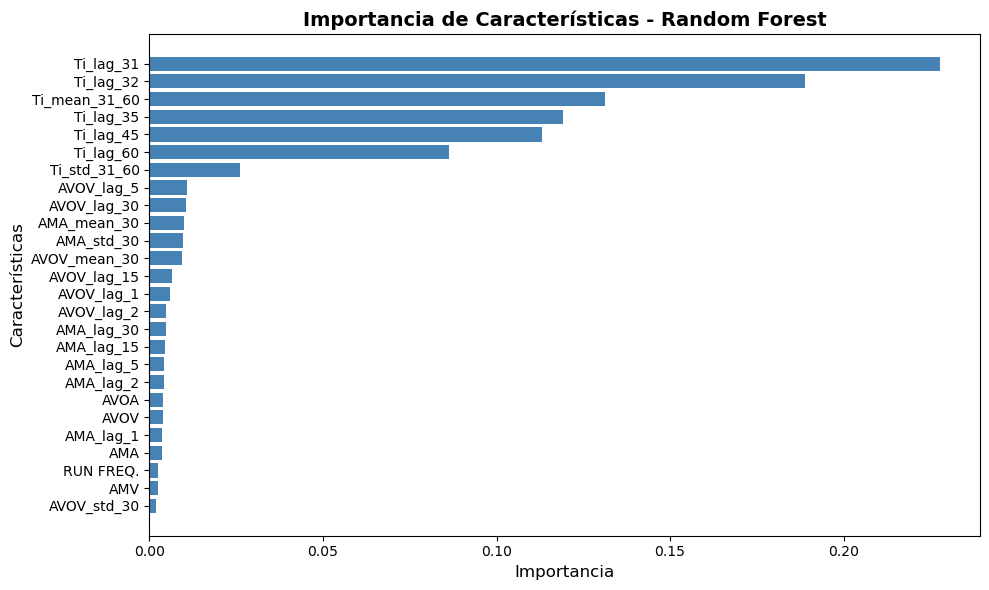


PARTICIPACIÓN PORCENTUAL:
      Feature  Participacion %
    Ti_lag_31            22.79
    Ti_lag_32            18.87
Ti_mean_31_60            13.13
    Ti_lag_35            11.91
    Ti_lag_45            11.30
    Ti_lag_60             8.63
 Ti_std_31_60             2.62
   AVOV_lag_5             1.07
  AVOV_lag_30             1.07
  AMA_mean_30             1.00
   AMA_std_30             0.97
 AVOV_mean_30             0.93
  AVOV_lag_15             0.65
   AVOV_lag_1             0.60
   AVOV_lag_2             0.49
   AMA_lag_30             0.47
   AMA_lag_15             0.44
    AMA_lag_5             0.43
    AMA_lag_2             0.41
         AVOA             0.40
         AVOV             0.39
    AMA_lag_1             0.36
          AMA             0.36
    RUN FREQ.             0.25
          AMV             0.24
  AVOV_std_30             0.20


In [49]:
# Importancia de las características en el modelo Random Forest
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("IMPORTANCIA DE CARACTERÍSTICAS - RANDOM FOREST")
print("=" * 50)
print(feature_importance.to_string(index=False))
print("=" * 50)

# Gráfico de importancia
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
plt.xlabel('Importancia', fontsize=12)
plt.ylabel('Características', fontsize=12)
plt.title('Importancia de Características - Random Forest', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Participación porcentual
feature_importance['Participacion %'] = (feature_importance['Importance'] / feature_importance['Importance'].sum() * 100).round(2)
print("\nPARTICIPACIÓN PORCENTUAL:")
print(feature_importance[['Feature', 'Participacion %']].to_string(index=False))

### Gradient Boosting

In [50]:
gbr = GradientBoostingRegressor(
    subsample=0.8,
    n_estimators=200,
    min_samples_split=10,
    min_samples_leaf=1,
    max_features=None,
    max_depth=3,
    learning_rate=0.01,
    random_state=42
    )
gbr.fit(X_train, y_train)

y_pred_gbr = gbr.predict(X_test)

### XGBRegresorr

In [51]:
# Modelo
xgb = XGBRegressor(
    subsample=0.8,
    n_estimators=200,
    min_samples_split=5,
    min_samples_leaf=1,
    max_features=None,
    max_depth=7,
    learning_rate=0.01,
    random_state=42,
    n_jobs=-1
)
# Entrenar
xgb.fit(X_train, y_train)

# Predicción
y_pred_xgb = xgb.predict(X_test)

c:\Users\lggom\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:50:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "min_samples_leaf", "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### LightGBM

In [52]:
# Modelo
lgbm = LGBMRegressor(
    subsample=0.8,
    reg_lambda=0,
    reg_alpha=0,
    num_leaves=20,
    n_estimators=100,
    min_child_weight=5,
    min_child_samples=20,
    max_depth=5,
    learning_rate=0.05,
    feature_fraction=0.7,
    colsample_bytree=1.0,
    bagging_fraction=0.7,
    random_state=42,
    n_jobs=-1
)
# Entrenar
lgbm.fit(X_train, y_train)
# Predicción
y_pred_lgbm = lgbm.predict(X_test)

[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.7, subsample=0.8 will be ignored. Current value: bagging_fraction=0.7
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.7, subsample=0.8 will be ignored. Current value: bagging_fraction=0.7
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,005625 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4911
[LightGBM] [Info] Number of data points in the train set: 730308, number of used features: 26
[LightGBM] [Info] Start training from score 142,566884
[LightGBM] [Warning] No furth

### Catboost

In [53]:
# Modelo
cat = CatBoostRegressor(
    subsample=0.9,
    min_child_samples=20,
    learning_rate=0.1,
    l2_leaf_reg=10,
    iterations=500,
    depth=3,
    colsample_bylevel=0.7,
    border_count=32
)

# Entrenar
cat.fit(X_train, y_train)
# Predicción
y_pred_cat = cat.predict(X_test)

0:	learn: 8.5693249	total: 22.4ms	remaining: 11.2s
1:	learn: 7.9460302	total: 43.9ms	remaining: 10.9s
2:	learn: 7.4016344	total: 65.7ms	remaining: 10.9s
3:	learn: 6.9235931	total: 87.5ms	remaining: 10.8s
4:	learn: 6.5084720	total: 109ms	remaining: 10.8s
5:	learn: 6.1485084	total: 131ms	remaining: 10.8s
6:	learn: 5.8533359	total: 153ms	remaining: 10.8s
7:	learn: 5.5808412	total: 174ms	remaining: 10.7s
8:	learn: 5.3606820	total: 197ms	remaining: 10.7s
9:	learn: 5.1520625	total: 219ms	remaining: 10.7s
10:	learn: 4.9734201	total: 242ms	remaining: 10.8s
11:	learn: 4.8196327	total: 266ms	remaining: 10.8s
12:	learn: 4.6925776	total: 292ms	remaining: 11s
13:	learn: 4.5818818	total: 326ms	remaining: 11.3s
14:	learn: 4.4864562	total: 351ms	remaining: 11.3s
15:	learn: 4.3998136	total: 375ms	remaining: 11.3s
16:	learn: 4.3290433	total: 394ms	remaining: 11.2s
17:	learn: 4.2673857	total: 414ms	remaining: 11.1s
18:	learn: 4.2148696	total: 436ms	remaining: 11s
19:	learn: 4.1712224	total: 458ms	remaini

### Evaluacion

In [54]:
def evaluar(y_true, y_pred, nombre):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"{nombre} -> RMSE: {rmse:.3f} | R2: {r2:.3f}")

evaluar(y_test, y_pred_lr,  "Linear Regression")
evaluar(y_test, y_pred_rf,  "Random Forest")
evaluar(y_test, y_pred_gbr, "Gradient Boosting")
evaluar(y_test, y_pred_xgb, "XGBoost")
evaluar(y_test, y_pred_lgbm, "LightGBM")
evaluar(y_test, y_pred_cat, "CatBoost")

Linear Regression -> RMSE: 0.252 | R2: 0.821
Random Forest -> RMSE: 0.255 | R2: 0.816
Gradient Boosting -> RMSE: 0.537 | R2: 0.187
XGBoost -> RMSE: 1.959 | R2: -9.835
LightGBM -> RMSE: 0.323 | R2: 0.705
CatBoost -> RMSE: 1.310 | R2: -3.844


In [55]:
# Crear tabla de evaluación
resultados = []

modelos = {
    "Linear Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gbr,
    "XGBoost": y_pred_xgb,
    "LightGBM": y_pred_lgbm,
    "CatBoost": y_pred_cat
}

for nombre, predicciones in modelos.items():
    mse = mean_squared_error(y_test, predicciones)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, predicciones)
    r2 = r2_score(y_test, predicciones)
    
    resultados.append({
        "Modelo": nombre,
        "RMSE": round(rmse, 4),
        "MAE": round(mae, 4),
        "R² Score": round(r2, 4),
        "MSE": round(mse, 4)
    })

tabla_evaluacion = pd.DataFrame(resultados)
tabla_evaluacion

,Modelo,RMSE,MAE,R² Score,MSE
0,Linear Regression,0.2521,0.0624,0.8205,0.0636
1,Random Forest,0.2550,0.0737,0.8163,0.0650
2,Gradient Boosting,0.5365,0.4437,0.1873,0.2878
3,XGBoost,1.9589,0.4301,-9.8347,3.8371
4,LightGBM,0.3234,0.0951,0.7046,0.1046
5,CatBoost,1.3098,0.1128,-3.8442,1.7156


### Grafica

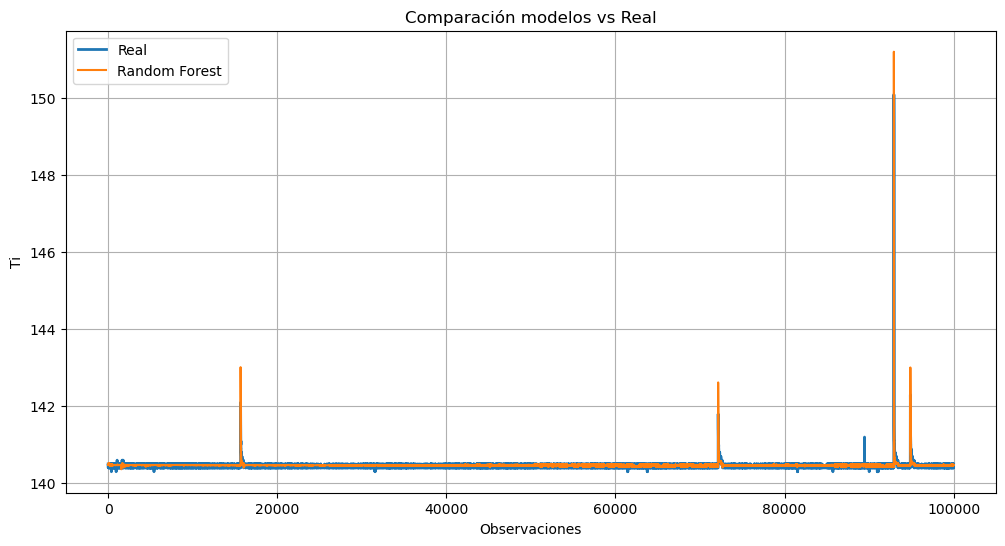

In [56]:
plt.figure(figsize=(12,6))

window_max=100000

plt.plot(y_test.values[:window_max], label='Real', linewidth=2)
#plt.plot(y_pred_lr[:window_max], label='Linear')
plt.plot(y_pred_rf[:window_max], label='Random Forest')
#plt.plot(y_pred_gbr[:window_max], label='GBR')
#plt.plot(y_pred_xgb[:window_max], label='XGB')
#plt.plot(y_pred_lgbm[:window_max], label='LightGBM')
#plt.plot(y_pred_cat[:window_max], label='CatBoost')

plt.legend()
plt.title('Comparación modelos vs Real')
plt.xlabel('Observaciones')
plt.ylabel('Ti')
plt.grid(True)

plt.show()

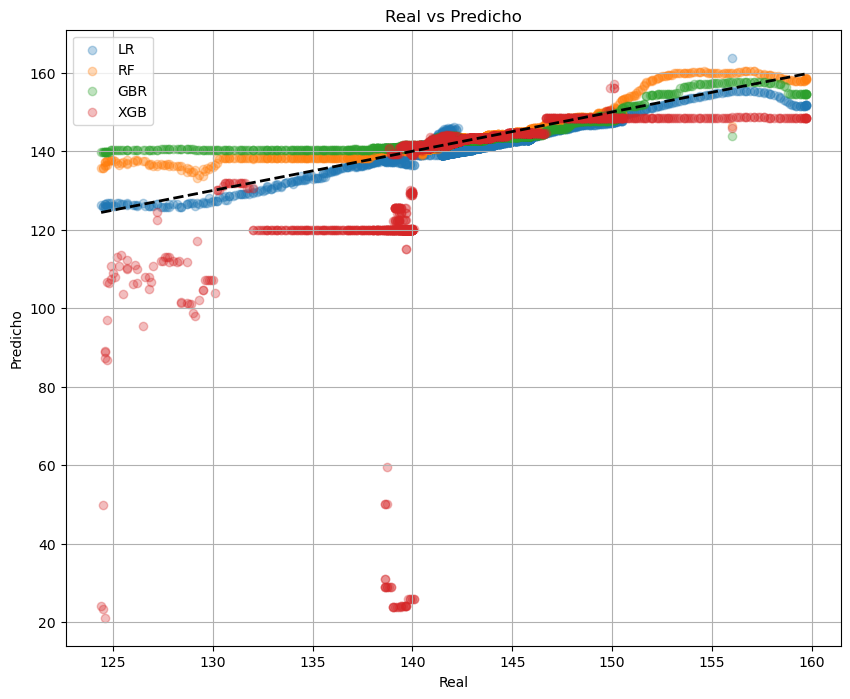

In [57]:
plt.figure(figsize=(10,8))

plt.scatter(y_test, y_pred_lr, alpha=0.3, label='LR')
plt.scatter(y_test, y_pred_rf, alpha=0.3, label='RF')
#plt.scatter(y_test, y_pred_svr, alpha=0.3, label='SVR')
plt.scatter(y_test, y_pred_gbr, alpha=0.3, label='GBR')
plt.scatter(y_test, y_pred_xgb, alpha=0.3, label='XGB')

# Línea ideal
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'k--', linewidth=2)

plt.xlabel('Real')
plt.ylabel('Predicho')
plt.title('Real vs Predicho')
plt.legend()
plt.grid(True)

plt.show()

In [58]:
print("Fecha inicial:", y_test.index.min())
print("Fecha final:", y_test.index.max())

Fecha inicial: 2025-12-07 10:07:34
Fecha final: 2026-04-23 21:42:30


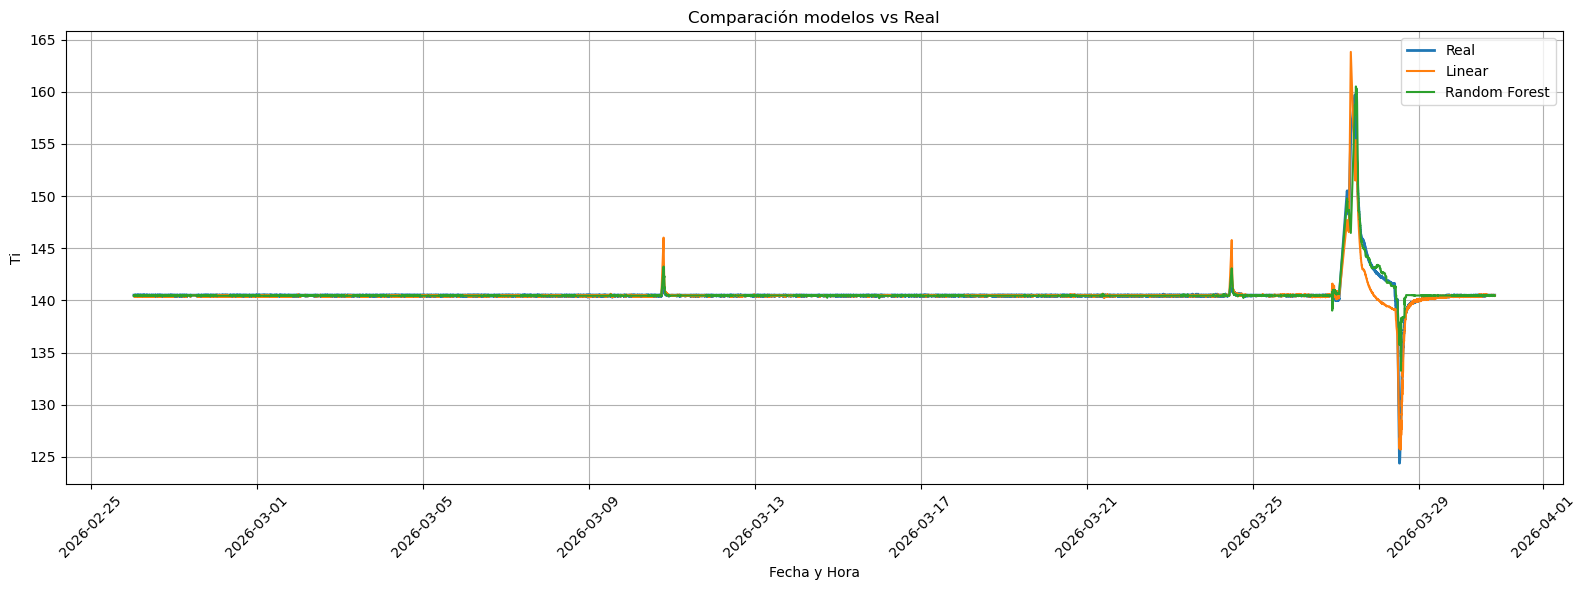

In [59]:
inicio = '2026-02-20 17:00:00'
fin    = '2026-03-30 20:00:00'

mask = (y_test.index >= inicio) & (y_test.index <= fin)

plt.figure(figsize=(16,6))

plt.plot(y_test.index[mask], y_test[mask], label='Real', linewidth=2)
plt.plot(y_test.index[mask], y_pred_lr[mask], label='Linear')
plt.plot(y_test.index[mask], y_pred_rf[mask], label='Random Forest')
#plt.plot(y_test.index[mask], y_pred_gbr[mask], label='GBR')
#plt.plot(y_test.index[mask], y_pred_xgb[mask], label='XGB')
# plt.plot(y_test.index[mask], y_pred_lr[mask], label='Linear')
#plt.plot(y_test.index[mask], y_pred_lgbm[mask], label='LightGBM')
#plt.plot(y_test.index[mask], y_pred_cat[mask], label='CatBoost')




plt.legend()
plt.title('Comparación modelos vs Real')
plt.xlabel('Fecha y Hora')
plt.ylabel('Ti')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Tm

In [30]:
features = [
    # variables originales
    'AMA',
    'AMV',
    'AVOA',
    'AVOV',
    'RUN FREQ.',
    # AMA temporal
    'AMA_lag_1',
    'AMA_lag_2',
    'AMA_lag_5',
    'AMA_lag_15',
    'AMA_lag_30',
    'AMA_mean_30',
    'AMA_std_30',
    # AVOV temporal
    'AVOV_lag_1',
    'AVOV_lag_2',
    'AVOV_lag_5',
    'AVOV_lag_15',
    'AVOV_lag_30',
    'AVOV_mean_30',
    'AVOV_std_30',
    # Tm temporal
    'Tm_lag_31',
    'Tm_lag_32',
    'Tm_lag_35',
    'Tm_lag_45',
    'Tm_lag_60',
    'Tm_mean_31_60',
    'Tm_std_31_60'
]

target = 'Tm'

df_model = df[features + [target]].copy()
X = df_model[features]
y = df_model[target]

In [31]:
# Garantizar que los datos estén ordenados por fecha
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)
print("="*60)

print("TRAIN")

print(f"Inicio : {X_train.index.min()}")
print(f"Fin    : {X_train.index.max()}")
print(f"Datos  : {len(X_train):,}")

print()

print("TEST")

print(f"Inicio : {X_test.index.min()}")
print(f"Fin    : {X_test.index.max()}")
print(f"Datos  : {len(X_test):,}")

print("="*60)

TRAIN
Inicio : 2024-01-01 01:00:30
Fin    : 2025-12-07 10:06:30
Datos  : 730,308

TEST
Inicio : 2025-12-07 10:07:34
Fin    : 2026-04-23 21:42:30
Datos  : 182,578


### Regresion lineal

In [32]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

### Random Forest

In [33]:
rf = RandomForestRegressor(
    n_estimators=200,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features='sqrt',
    max_depth=10,
    random_state=42,
    n_jobs=-1
    )
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

IMPORTANCIA DE CARACTERÍSTICAS - RANDOM FOREST
      Feature  Importance
    Tm_lag_31    0.205815
    Tm_lag_32    0.168019
Tm_mean_31_60    0.151414
    Tm_lag_45    0.105258
    Tm_lag_35    0.088816
    Tm_lag_60    0.077113
         AVOA    0.041202
    AMA_lag_1    0.034041
   AMA_lag_15    0.020931
    AMA_lag_5    0.019373
          AMA    0.017103
   AMA_lag_30    0.016298
    AMA_lag_2    0.013969
  AMA_mean_30    0.012685
 Tm_std_31_60    0.010472
   AMA_std_30    0.003751
          AMV    0.001958
   AVOV_lag_1    0.001655
   AVOV_lag_2    0.001621
  AVOV_lag_30    0.001574
 AVOV_mean_30    0.001543
   AVOV_lag_5    0.001489
    RUN FREQ.    0.001353
  AVOV_lag_15    0.001090
         AVOV    0.000920
  AVOV_std_30    0.000537


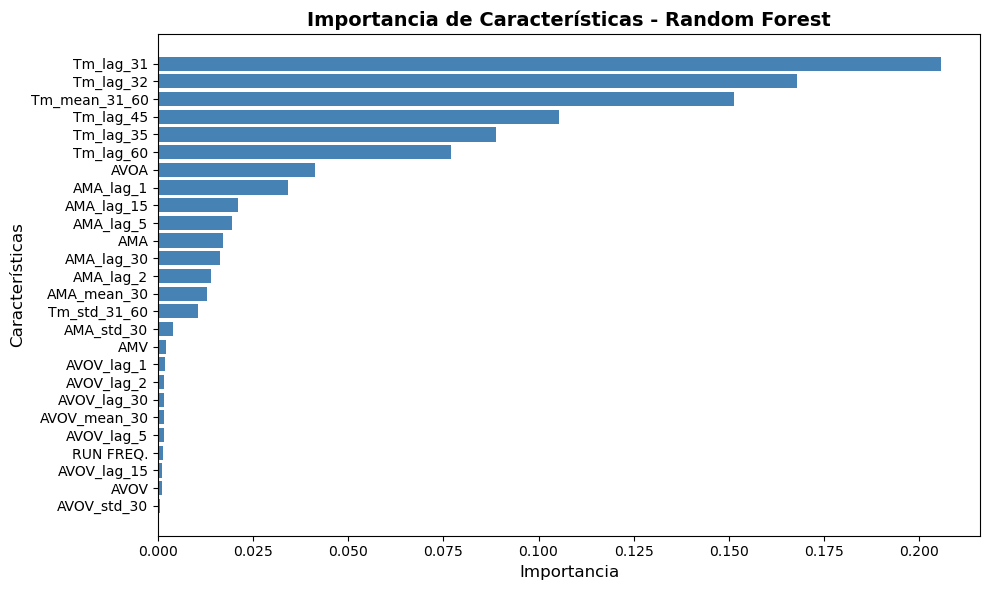


PARTICIPACIÓN PORCENTUAL:
      Feature  Participacion %
    Tm_lag_31            20.58
    Tm_lag_32            16.80
Tm_mean_31_60            15.14
    Tm_lag_45            10.53
    Tm_lag_35             8.88
    Tm_lag_60             7.71
         AVOA             4.12
    AMA_lag_1             3.40
   AMA_lag_15             2.09
    AMA_lag_5             1.94
          AMA             1.71
   AMA_lag_30             1.63
    AMA_lag_2             1.40
  AMA_mean_30             1.27
 Tm_std_31_60             1.05
   AMA_std_30             0.38
          AMV             0.20
   AVOV_lag_1             0.17
   AVOV_lag_2             0.16
  AVOV_lag_30             0.16
 AVOV_mean_30             0.15
   AVOV_lag_5             0.15
    RUN FREQ.             0.14
  AVOV_lag_15             0.11
         AVOV             0.09
  AVOV_std_30             0.05


In [34]:
# Importancia de las características en el modelo Random Forest
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("IMPORTANCIA DE CARACTERÍSTICAS - RANDOM FOREST")
print("=" * 50)
print(feature_importance.to_string(index=False))
print("=" * 50)

# Gráfico de importancia
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
plt.xlabel('Importancia', fontsize=12)
plt.ylabel('Características', fontsize=12)
plt.title('Importancia de Características - Random Forest', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Participación porcentual
feature_importance['Participacion %'] = (feature_importance['Importance'] / feature_importance['Importance'].sum() * 100).round(2)
print("\nPARTICIPACIÓN PORCENTUAL:")
print(feature_importance[['Feature', 'Participacion %']].to_string(index=False))

### Gradient Boosting

In [35]:
gbr = GradientBoostingRegressor(
    subsample=0.8,
    n_estimators=200,
    min_samples_split=10,
    min_samples_leaf=1,
    max_features=None,
    max_depth=3,
    learning_rate=0.01,
    random_state=42
    )
gbr.fit(X_train, y_train)

y_pred_gbr = gbr.predict(X_test)

### XGBRegresorr

In [36]:
# Modelo
xgb = XGBRegressor(
    subsample=0.8,
    n_estimators=200,
    min_samples_split=5,
    min_samples_leaf=1,
    max_features=None,
    max_depth=7,
    learning_rate=0.01,
    random_state=42,
    n_jobs=-1
)
# Entrenar
xgb.fit(X_train, y_train)

# Predicción
y_pred_xgb = xgb.predict(X_test)

c:\Users\lggom\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:44:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "min_samples_leaf", "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### LightGBM

In [37]:
# Modelo
lgbm = LGBMRegressor(
    subsample=0.8,
    reg_lambda=0,
    reg_alpha=0,
    num_leaves=20,
    n_estimators=100,
    min_child_weight=5,
    min_child_samples=20,
    max_depth=5,
    learning_rate=0.05,
    feature_fraction=0.7,
    colsample_bytree=1.0,
    bagging_fraction=0.7,
    random_state=42,
    n_jobs=-1
)
# Entrenar
lgbm.fit(X_train, y_train)
# Predicción
y_pred_lgbm = lgbm.predict(X_test)

[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.7, subsample=0.8 will be ignored. Current value: bagging_fraction=0.7
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.7, subsample=0.8 will be ignored. Current value: bagging_fraction=0.7
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0,028290 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4911
[LightGBM] [Info] Number of data points in the train set: 730308, number of used features: 26
[LightGBM] [Info] Start training from score 170,839273
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warnin

### Catboost

In [38]:
# Modelo
cat = CatBoostRegressor(
    subsample=0.9,
    min_child_samples=20,
    learning_rate=0.1,
    l2_leaf_reg=10,
    iterations=500,
    depth=3,
    colsample_bylevel=0.7,
    border_count=32
)

# Entrenar
cat.fit(X_train, y_train)
# Predicción
y_pred_cat = cat.predict(X_test)

0:	learn: 18.1322734	total: 23.3ms	remaining: 11.6s
1:	learn: 16.5992609	total: 46.9ms	remaining: 11.7s
2:	learn: 15.2774174	total: 70.1ms	remaining: 11.6s
3:	learn: 14.0545496	total: 93.3ms	remaining: 11.6s
4:	learn: 13.0032710	total: 115ms	remaining: 11.4s
5:	learn: 12.0823773	total: 139ms	remaining: 11.5s
6:	learn: 11.2806780	total: 163ms	remaining: 11.5s
7:	learn: 10.5374217	total: 187ms	remaining: 11.5s
8:	learn: 9.8709832	total: 211ms	remaining: 11.5s
9:	learn: 9.2947063	total: 235ms	remaining: 11.5s
10:	learn: 8.8005436	total: 259ms	remaining: 11.5s
11:	learn: 8.3492501	total: 283ms	remaining: 11.5s
12:	learn: 7.9794936	total: 304ms	remaining: 11.4s
13:	learn: 7.6570457	total: 327ms	remaining: 11.4s
14:	learn: 7.3620277	total: 351ms	remaining: 11.3s
15:	learn: 7.1088199	total: 375ms	remaining: 11.3s
16:	learn: 6.8904731	total: 398ms	remaining: 11.3s
17:	learn: 6.7082821	total: 421ms	remaining: 11.3s
18:	learn: 6.5324720	total: 445ms	remaining: 11.3s
19:	learn: 6.3912519	total: 4

### Evaluacion

In [39]:
def evaluar(y_true, y_pred, nombre):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"{nombre} -> RMSE: {rmse:.3f} | R2: {r2:.3f}")

evaluar(y_test, y_pred_lr,  "Linear Regression")
evaluar(y_test, y_pred_rf,  "Random Forest")
evaluar(y_test, y_pred_gbr, "Gradient Boosting")
evaluar(y_test, y_pred_xgb, "XGBoost")
evaluar(y_test, y_pred_lgbm, "LightGBM")
evaluar(y_test, y_pred_cat, "CatBoost")

Linear Regression -> RMSE: 0.650 | R2: 0.980
Random Forest -> RMSE: 0.774 | R2: 0.971
Gradient Boosting -> RMSE: 2.882 | R2: 0.604
XGBoost -> RMSE: 3.156 | R2: 0.526
LightGBM -> RMSE: 0.719 | R2: 0.975
CatBoost -> RMSE: 1.764 | R2: 0.852


In [40]:
# Crear tabla de evaluación
resultados = []

modelos = {
    "Linear Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gbr,
    "XGBoost": y_pred_xgb,
    "LightGBM": y_pred_lgbm,
    "CatBoost": y_pred_cat
}

for nombre, predicciones in modelos.items():
    mse = mean_squared_error(y_test, predicciones)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, predicciones)
    r2 = r2_score(y_test, predicciones)
    
    resultados.append({
        "Modelo": nombre,
        "RMSE": round(rmse, 4),
        "MAE": round(mae, 4),
        "R² Score": round(r2, 4),
        "MSE": round(mse, 4)
    })

tabla_evaluacion = pd.DataFrame(resultados)
tabla_evaluacion

,Modelo,RMSE,MAE,R² Score,MSE
0,Linear Regression,0.6498,0.4965,0.9799,0.4222
1,Random Forest,0.7742,0.5744,0.9714,0.5994
2,Gradient Boosting,2.8821,2.8355,0.6043,8.3066
3,XGBoost,3.1556,3.0241,0.5257,9.9579
4,LightGBM,0.7190,0.4574,0.9754,0.5170
5,CatBoost,1.7645,1.2503,0.8517,3.1134


### Grafica

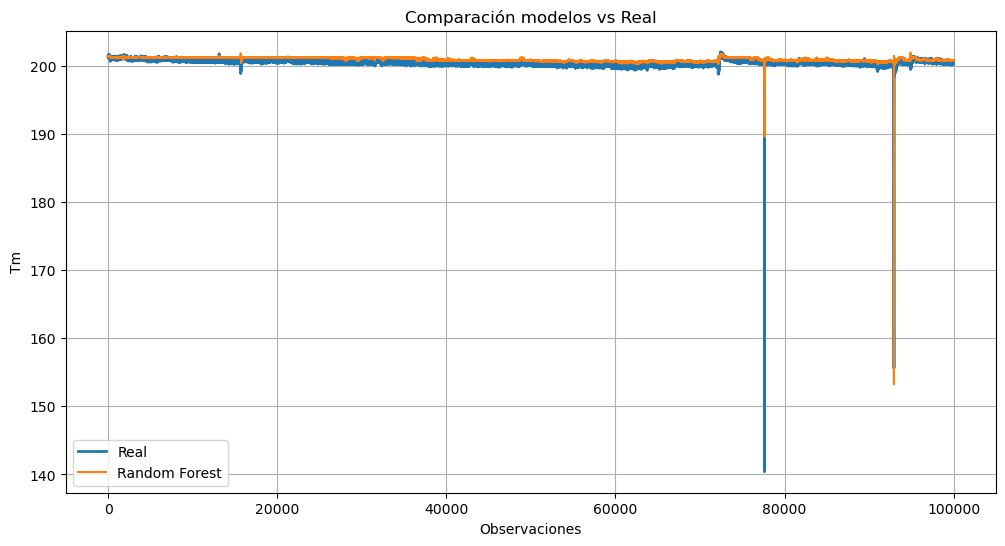

In [41]:
plt.figure(figsize=(12,6))

window_max=100000

plt.plot(y_test.values[:window_max], label='Real', linewidth=2)
#plt.plot(y_pred_lr[:window_max], label='Linear')
plt.plot(y_pred_rf[:window_max], label='Random Forest')
#plt.plot(y_pred_gbr[:window_max], label='GBR')
#plt.plot(y_pred_xgb[:window_max], label='XGB')
#plt.plot(y_pred_lgbm[:window_max], label='LightGBM')
#plt.plot(y_pred_cat[:window_max], label='CatBoost')

plt.legend()
plt.title('Comparación modelos vs Real')
plt.xlabel('Observaciones')
plt.ylabel('Tm')
plt.grid(True)

plt.show()

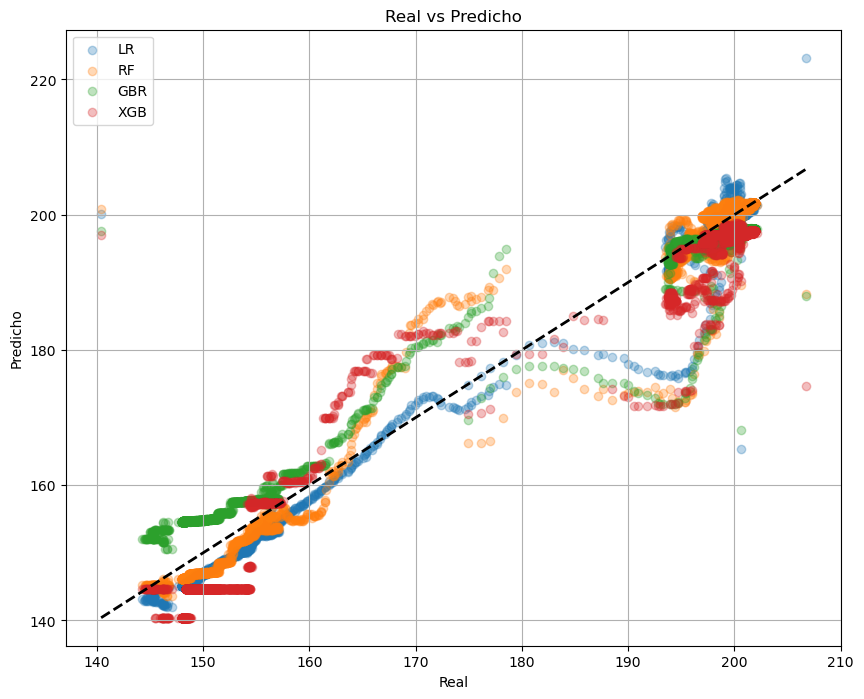

In [42]:
plt.figure(figsize=(10,8))

plt.scatter(y_test, y_pred_lr, alpha=0.3, label='LR')
plt.scatter(y_test, y_pred_rf, alpha=0.3, label='RF')
#plt.scatter(y_test, y_pred_svr, alpha=0.3, label='SVR')
plt.scatter(y_test, y_pred_gbr, alpha=0.3, label='GBR')
plt.scatter(y_test, y_pred_xgb, alpha=0.3, label='XGB')

# Línea ideal
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'k--', linewidth=2)

plt.xlabel('Real')
plt.ylabel('Predicho')
plt.title('Real vs Predicho')
plt.legend()
plt.grid(True)

plt.show()

In [43]:
print("Fecha inicial:", y_test.index.min())
print("Fecha final:", y_test.index.max())

Fecha inicial: 2025-12-07 10:07:34
Fecha final: 2026-04-23 21:42:30


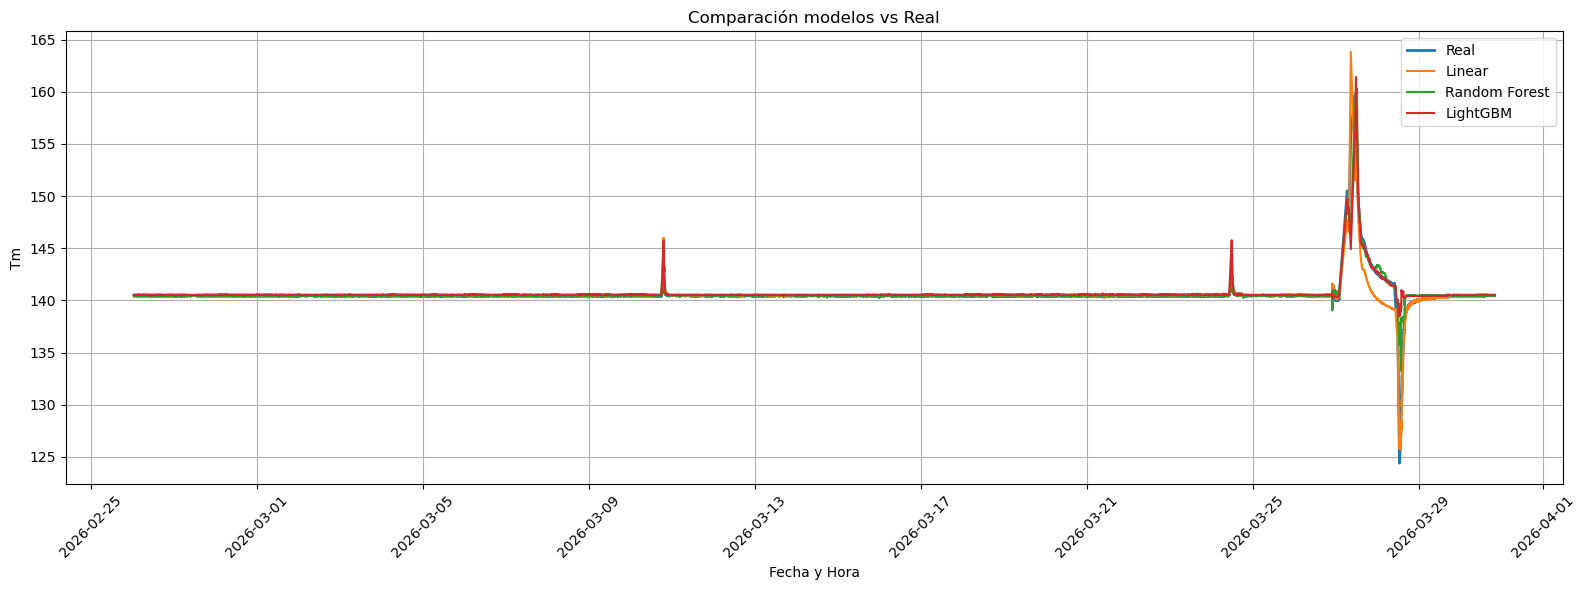

In [60]:
inicio = '2026-02-20 17:00:00'
fin    = '2026-03-30 20:00:00'

mask = (y_test.index >= inicio) & (y_test.index <= fin)

plt.figure(figsize=(16,6))

plt.plot(y_test.index[mask], y_test[mask], label='Real', linewidth=2)
plt.plot(y_test.index[mask], y_pred_lr[mask], label='Linear')
plt.plot(y_test.index[mask], y_pred_rf[mask], label='Random Forest')
#plt.plot(y_test.index[mask], y_pred_gbr[mask], label='GBR')
#plt.plot(y_test.index[mask], y_pred_xgb[mask], label='XGB')
# plt.plot(y_test.index[mask], y_pred_lr[mask], label='Linear')
plt.plot(y_test.index[mask], y_pred_lgbm[mask], label='LightGBM')
#plt.plot(y_test.index[mask], y_pred_cat[mask], label='CatBoost')




plt.legend()
plt.title('Comparación modelos vs Real')
plt.xlabel('Fecha y Hora')
plt.ylabel('Tm')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Vx

In [48]:
features = [
    # variables originales
    'AMA',
    'AMV',
    'AVOA',
    'AVOV',
    'RUN FREQ.',
    # AMA temporal
    'AMA_lag_1',
    'AMA_lag_2',
    'AMA_lag_5',
    'AMA_lag_15',
    'AMA_lag_30',
    'AMA_mean_30',
    'AMA_std_30',
    # AVOV temporal
    'AVOV_lag_1',
    'AVOV_lag_2',
    'AVOV_lag_5',
    'AVOV_lag_15',
    'AVOV_lag_30',
    'AVOV_mean_30',
    'AVOV_std_30',
    # VX temporal
    'VX_lag_31',
    'VX_lag_32',
    'VX_lag_35',
    'VX_lag_45',
    'VX_lag_60',
    'VX_mean_31_60',
    'VX_std_31_60'
]

target = 'VX'

df_model = df[features + [target]].copy()
X = df_model[features]
y = df_model[target]

In [49]:
# Garantizar que los datos estén ordenados por fecha
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)
print("="*60)

print("TRAIN")

print(f"Inicio : {X_train.index.min()}")
print(f"Fin    : {X_train.index.max()}")
print(f"Datos  : {len(X_train):,}")

print()

print("TEST")

print(f"Inicio : {X_test.index.min()}")
print(f"Fin    : {X_test.index.max()}")
print(f"Datos  : {len(X_test):,}")

print("="*60)

TRAIN
Inicio : 2024-01-01 03:00:30
Fin    : 2025-12-07 10:08:30
Datos  : 730,305

TEST
Inicio : 2025-12-07 10:09:30
Fin    : 2026-04-23 21:42:30
Datos  : 182,577


### Regresion lineal

In [50]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

### Random Forest

In [51]:
rf = RandomForestRegressor(
    n_estimators=200,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features='sqrt',
    max_depth=10,
    random_state=42,
    n_jobs=-1
    )
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

IMPORTANCIA DE CARACTERÍSTICAS - RANDOM FOREST
      Feature  Importance
VX_mean_31_60    0.252745
    VX_lag_31    0.114933
    VX_lag_35    0.109405
    VX_lag_32    0.094689
    VX_lag_45    0.078141
    VX_lag_60    0.059261
    AMA_lag_1    0.051643
  AMA_mean_30    0.046802
    AMA_lag_5    0.030012
         AVOA    0.027923
          AMA    0.025680
    AMA_lag_2    0.022807
   AMA_lag_15    0.013035
   AMA_lag_30    0.010447
   AMA_std_30    0.009072
    RUN FREQ.    0.006830
  AVOV_lag_30    0.006706
          AMV    0.006019
 AVOV_mean_30    0.005884
         AVOV    0.005364
 VX_std_31_60    0.004835
  AVOV_lag_15    0.004693
   AVOV_lag_1    0.004467
   AVOV_lag_5    0.003986
   AVOV_lag_2    0.003889
  AVOV_std_30    0.000733


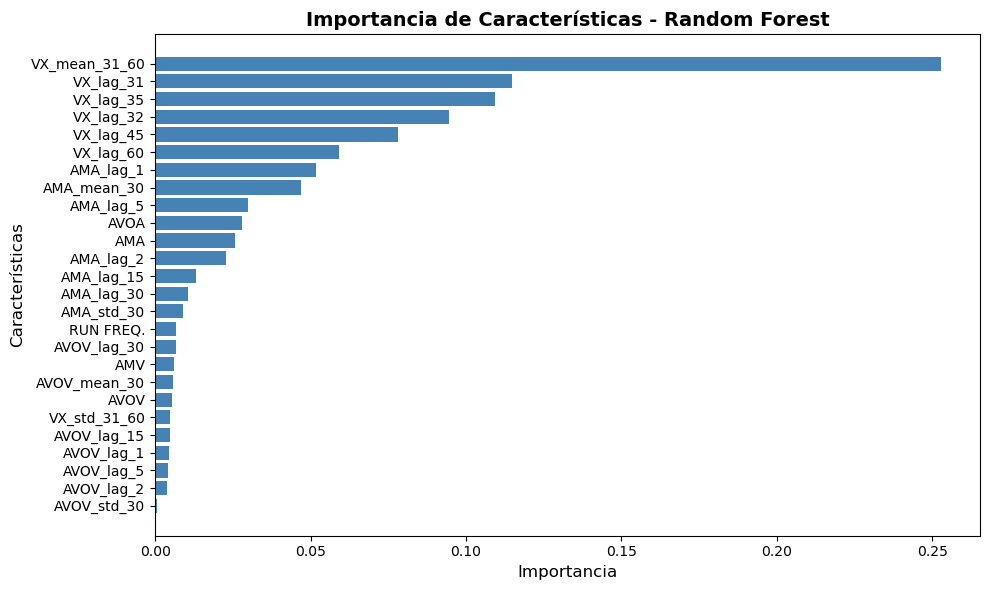


PARTICIPACIÓN PORCENTUAL:
      Feature  Participacion %
VX_mean_31_60            25.27
    VX_lag_31            11.49
    VX_lag_35            10.94
    VX_lag_32             9.47
    VX_lag_45             7.81
    VX_lag_60             5.93
    AMA_lag_1             5.16
  AMA_mean_30             4.68
    AMA_lag_5             3.00
         AVOA             2.79
          AMA             2.57
    AMA_lag_2             2.28
   AMA_lag_15             1.30
   AMA_lag_30             1.04
   AMA_std_30             0.91
    RUN FREQ.             0.68
  AVOV_lag_30             0.67
          AMV             0.60
 AVOV_mean_30             0.59
         AVOV             0.54
 VX_std_31_60             0.48
  AVOV_lag_15             0.47
   AVOV_lag_1             0.45
   AVOV_lag_5             0.40
   AVOV_lag_2             0.39
  AVOV_std_30             0.07


In [52]:
# Importancia de las características en el modelo Random Forest
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("IMPORTANCIA DE CARACTERÍSTICAS - RANDOM FOREST")
print("=" * 50)
print(feature_importance.to_string(index=False))
print("=" * 50)

# Gráfico de importancia
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
plt.xlabel('Importancia', fontsize=12)
plt.ylabel('Características', fontsize=12)
plt.title('Importancia de Características - Random Forest', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Participación porcentual
feature_importance['Participacion %'] = (feature_importance['Importance'] / feature_importance['Importance'].sum() * 100).round(2)
print("\nPARTICIPACIÓN PORCENTUAL:")
print(feature_importance[['Feature', 'Participacion %']].to_string(index=False))

### Gradient Boosting

In [53]:
gbr = GradientBoostingRegressor(
    subsample=0.8,
    n_estimators=200,
    min_samples_split=10,
    min_samples_leaf=1,
    max_features=None,
    max_depth=3,
    learning_rate=0.01,
    random_state=42
    )
gbr.fit(X_train, y_train)

y_pred_gbr = gbr.predict(X_test)

### XGBRegresorr

In [54]:
# Modelo
xgb = XGBRegressor(
    subsample=0.8,
    n_estimators=200,
    min_samples_split=5,
    min_samples_leaf=1,
    max_features=None,
    max_depth=7,
    learning_rate=0.01,
    random_state=42,
    n_jobs=-1
)
# Entrenar
xgb.fit(X_train, y_train)

# Predicción
y_pred_xgb = xgb.predict(X_test)

c:\Users\lggom\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:11:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "min_samples_leaf", "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### LightGBM

In [55]:
# Modelo
lgbm = LGBMRegressor(
    subsample=0.8,
    reg_lambda=0,
    reg_alpha=0,
    num_leaves=20,
    n_estimators=100,
    min_child_weight=5,
    min_child_samples=20,
    max_depth=5,
    learning_rate=0.05,
    feature_fraction=0.7,
    colsample_bytree=1.0,
    bagging_fraction=0.7,
    random_state=42,
    n_jobs=-1
)
# Entrenar
lgbm.fit(X_train, y_train)
# Predicción
y_pred_lgbm = lgbm.predict(X_test)

[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.7, subsample=0.8 will be ignored. Current value: bagging_fraction=0.7
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.7, subsample=0.8 will be ignored. Current value: bagging_fraction=0.7
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0,034542 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4923
[LightGBM] [Info] Number of data points in the train set: 730305, number of used features: 26
[LightGBM] [Info] Start training from score 0,207770
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current

### Catboost

In [56]:
# Modelo
cat = CatBoostRegressor(
    subsample=0.9,
    min_child_samples=20,
    learning_rate=0.1,
    l2_leaf_reg=10,
    iterations=500,
    depth=3,
    colsample_bylevel=0.7,
    border_count=32
)

# Entrenar
cat.fit(X_train, y_train)
# Predicción
y_pred_cat = cat.predict(X_test)

0:	learn: 0.0616650	total: 24.5ms	remaining: 12.2s
1:	learn: 0.0578941	total: 49.2ms	remaining: 12.2s
2:	learn: 0.0546219	total: 75.2ms	remaining: 12.5s
3:	learn: 0.0516712	total: 101ms	remaining: 12.5s
4:	learn: 0.0490815	total: 125ms	remaining: 12.4s
5:	learn: 0.0469515	total: 151ms	remaining: 12.4s
6:	learn: 0.0450290	total: 176ms	remaining: 12.4s
7:	learn: 0.0433648	total: 198ms	remaining: 12.2s
8:	learn: 0.0419288	total: 223ms	remaining: 12.1s
9:	learn: 0.0406985	total: 247ms	remaining: 12.1s
10:	learn: 0.0396910	total: 273ms	remaining: 12.1s
11:	learn: 0.0388422	total: 299ms	remaining: 12.2s
12:	learn: 0.0381052	total: 326ms	remaining: 12.2s
13:	learn: 0.0374304	total: 352ms	remaining: 12.2s
14:	learn: 0.0368416	total: 379ms	remaining: 12.3s
15:	learn: 0.0363740	total: 406ms	remaining: 12.3s
16:	learn: 0.0359558	total: 432ms	remaining: 12.3s
17:	learn: 0.0356364	total: 454ms	remaining: 12.1s
18:	learn: 0.0353196	total: 477ms	remaining: 12.1s
19:	learn: 0.0350736	total: 502ms	rema

### Evaluacion

In [57]:
def evaluar(y_true, y_pred, nombre):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"{nombre} -> RMSE: {rmse:.3f} | R2: {r2:.3f}")

evaluar(y_test, y_pred_lr,  "Linear Regression")
evaluar(y_test, y_pred_rf,  "Random Forest")
evaluar(y_test, y_pred_gbr, "Gradient Boosting")
evaluar(y_test, y_pred_xgb, "XGBoost")
evaluar(y_test, y_pred_lgbm, "LightGBM")
evaluar(y_test, y_pred_cat, "CatBoost")

Linear Regression -> RMSE: 0.048 | R2: 0.725
Random Forest -> RMSE: 0.071 | R2: 0.405
Gradient Boosting -> RMSE: 0.064 | R2: 0.514
XGBoost -> RMSE: 0.063 | R2: 0.525
LightGBM -> RMSE: 0.065 | R2: 0.492
CatBoost -> RMSE: 0.064 | R2: 0.517


In [58]:
# Crear tabla de evaluación
resultados = []

modelos = {
    "Linear Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gbr,
    "XGBoost": y_pred_xgb,
    "LightGBM": y_pred_lgbm,
    "CatBoost": y_pred_cat
}

for nombre, predicciones in modelos.items():
    mse = mean_squared_error(y_test, predicciones)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, predicciones)
    r2 = r2_score(y_test, predicciones)
    
    resultados.append({
        "Modelo": nombre,
        "RMSE": round(rmse, 4),
        "MAE": round(mae, 4),
        "R² Score": round(r2, 4),
        "MSE": round(mse, 4)
    })

tabla_evaluacion = pd.DataFrame(resultados)
tabla_evaluacion

,Modelo,RMSE,MAE,R² Score,MSE
0,Linear Regression,0.0480,0.0330,0.7248,0.0023
1,Random Forest,0.0705,0.0410,0.4045,0.0050
2,Gradient Boosting,0.0637,0.0384,0.5145,0.0041
3,XGBoost,0.0630,0.0380,0.5255,0.0040
4,LightGBM,0.0652,0.0389,0.4919,0.0042
5,CatBoost,0.0635,0.0382,0.5170,0.0040


### Grafica

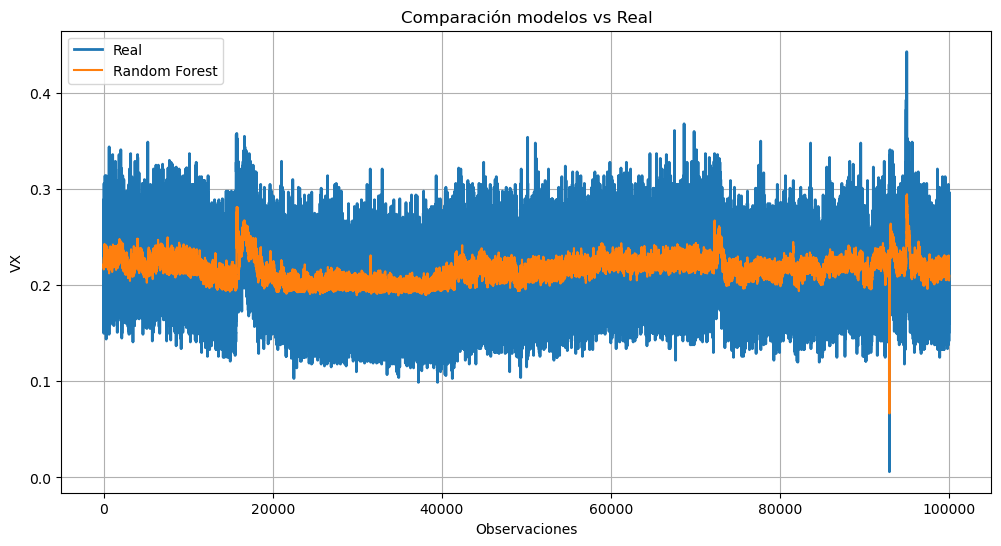

In [59]:
plt.figure(figsize=(12,6))

window_max=100000

plt.plot(y_test.values[:window_max], label='Real', linewidth=2)
#plt.plot(y_pred_lr[:window_max], label='Linear')
plt.plot(y_pred_rf[:window_max], label='Random Forest')
#plt.plot(y_pred_gbr[:window_max], label='GBR')
#plt.plot(y_pred_xgb[:window_max], label='XGB')
#plt.plot(y_pred_lgbm[:window_max], label='LightGBM')
#plt.plot(y_pred_cat[:window_max], label='CatBoost')

plt.legend()
plt.title('Comparación modelos vs Real')
plt.xlabel('Observaciones')
plt.ylabel('VX')
plt.grid(True)

plt.show()

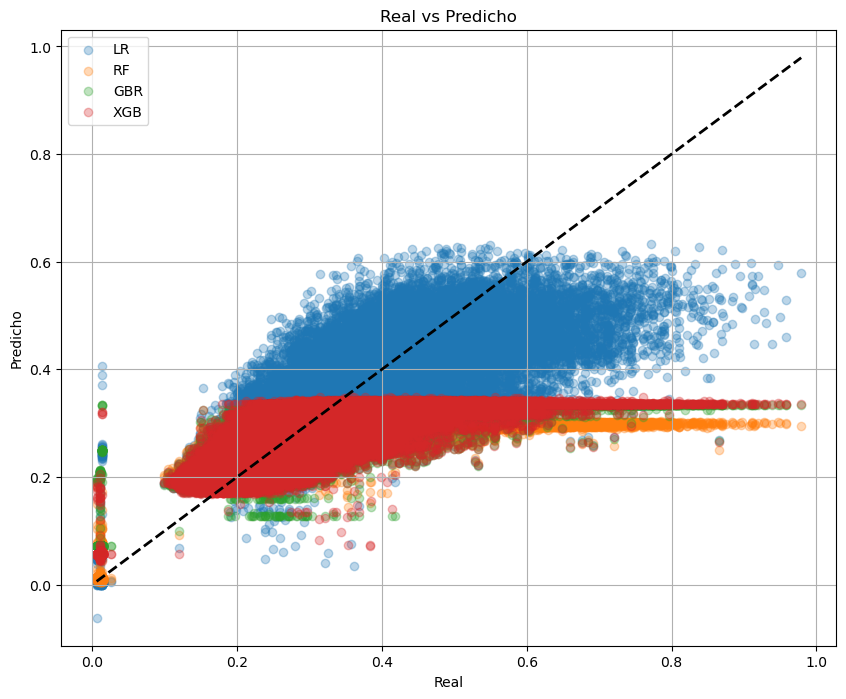

In [60]:
plt.figure(figsize=(10,8))

plt.scatter(y_test, y_pred_lr, alpha=0.3, label='LR')
plt.scatter(y_test, y_pred_rf, alpha=0.3, label='RF')
#plt.scatter(y_test, y_pred_svr, alpha=0.3, label='SVR')
plt.scatter(y_test, y_pred_gbr, alpha=0.3, label='GBR')
plt.scatter(y_test, y_pred_xgb, alpha=0.3, label='XGB')

# Línea ideal
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'k--', linewidth=2)

plt.xlabel('Real')
plt.ylabel('Predicho')
plt.title('Real vs Predicho')
plt.legend()
plt.grid(True)

plt.show()

In [61]:
print("Fecha inicial:", y_test.index.min())
print("Fecha final:", y_test.index.max())

Fecha inicial: 2025-12-07 10:09:30
Fecha final: 2026-04-23 21:42:30


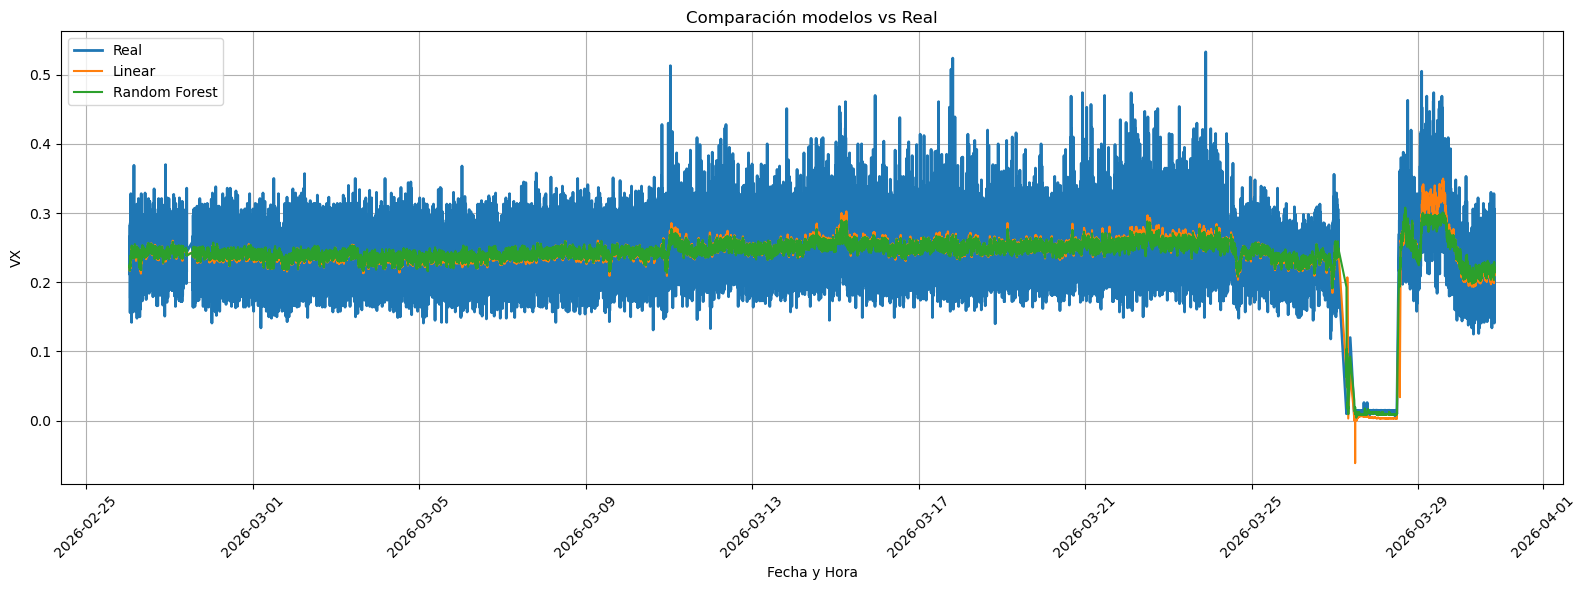

In [62]:
inicio = '2026-02-20 17:00:00'
fin    = '2026-03-30 20:00:00'

mask = (y_test.index >= inicio) & (y_test.index <= fin)

plt.figure(figsize=(16,6))

plt.plot(y_test.index[mask], y_test[mask], label='Real', linewidth=2)
plt.plot(y_test.index[mask], y_pred_lr[mask], label='Linear')
plt.plot(y_test.index[mask], y_pred_rf[mask], label='Random Forest')
#plt.plot(y_test.index[mask], y_pred_gbr[mask], label='GBR')
#plt.plot(y_test.index[mask], y_pred_xgb[mask], label='XGB')
# plt.plot(y_test.index[mask], y_pred_lr[mask], label='Linear')
#plt.plot(y_test.index[mask], y_pred_lgbm[mask], label='LightGBM')
#plt.plot(y_test.index[mask], y_pred_cat[mask], label='CatBoost')




plt.legend()
plt.title('Comparación modelos vs Real')
plt.xlabel('Fecha y Hora')
plt.ylabel('VX')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Revision cruzada

In [91]:
# =====================================================
# VALIDACIÓN CRUZADA TEMPORAL Random Forest
# =====================================================

tscv = TimeSeriesSplit(n_splits=5)

results = []

fold = 1

for train_index, test_index in tscv.split(X):

    # división temporal
    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    # =================================================
    # MODELO RANDOM FOREST
    # =================================================

    #model = RandomForestRegressor(n_estimators=100, random_state=42)
    model = RandomForestRegressor(
    n_estimators=200,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features='sqrt',
    max_depth=20,
    random_state=42,
    n_jobs=-1
    )
    # entrenamiento
    model.fit(X_train, y_train)

    # predicción
    y_pred = model.predict(X_test)

    # =================================================
    # MÉTRICAS
    # =================================================

    mae = mean_absolute_error(y_test, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_test, y_pred)
    )

    r2 = r2_score(y_test, y_pred)

    # fechas del fold
    train_dates = X_train.index
    test_dates = X_test.index

    # guardar resultados
    results.append({
        'Fold': fold,

        'Train Start': train_dates.min(),
        'Train End': train_dates.max(),

        'Test Start': test_dates.min(),
        'Test End': test_dates.max(),

        'Train Size': len(train_index),
        'Test Size': len(test_index),

        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    })

    # =================================================
    # IMPRESIÓN
    # =================================================

    print("\n" + "="*60)

    print(f"FOLD {fold}")

    print("-"*60)

    print(f"TRAIN:")
    print(f"Inicio: {train_dates.min()}")
    print(f"Fin   : {train_dates.max()}")
    print(f"Datos : {len(train_index):,}")

    print()

    print(f"TEST:")
    print(f"Inicio: {test_dates.min()}")
    print(f"Fin   : {test_dates.max()}")
    print(f"Datos : {len(test_index):,}")

    print()

    print("MÉTRICAS:")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}")

    fold += 1

# =====================================================
# RESUMEN FINAL
# =====================================================

results_df = pd.DataFrame(results)

print("\n" + "="*60)
print("RESUMEN VALIDACIÓN CRUZADA")
print("="*60)

print(results_df)

print("\nPROMEDIO MÉTRICAS")

print(
    results_df[['MAE', 'RMSE', 'R2']].mean()
)


FOLD 1
------------------------------------------------------------
TRAIN:
Inicio: 2024-01-01 00:30:31
Fin   : 2024-06-05 08:42:30
Datos : 152,985

TEST:
Inicio: 2024-06-05 08:43:30
Fin   : 2024-10-02 04:55:30
Datos : 152,981

MÉTRICAS:
MAE  : 0.1200
RMSE : 0.3134
R2   : -0.3503

FOLD 2
------------------------------------------------------------
TRAIN:
Inicio: 2024-01-01 00:30:31
Fin   : 2024-10-02 04:55:30
Datos : 305,966

TEST:
Inicio: 2024-10-02 04:56:30
Fin   : 2025-01-31 21:27:30
Datos : 152,981

MÉTRICAS:
MAE  : 3.0207
RMSE : 8.4382
R2   : 0.0209

FOLD 3
------------------------------------------------------------
TRAIN:
Inicio: 2024-01-01 00:30:31
Fin   : 2025-01-31 21:27:30
Datos : 458,947

TEST:
Inicio: 2025-01-31 21:28:30
Fin   : 2025-09-06 13:24:32
Datos : 152,981

MÉTRICAS:
MAE  : 8.4102
RMSE : 22.1617
R2   : -1.0599

FOLD 4
------------------------------------------------------------
TRAIN:
Inicio: 2024-01-01 00:30:31
Fin   : 2025-09-06 13:24:32
Datos : 611,928

TEST:
In

# Hyperpareter tunning

## Random forest Hypertunning

In [57]:
tscv = TimeSeriesSplit(n_splits=5)

param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}

rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

In [58]:
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,                      # número de combinaciones aleatorias
    cv=tscv,                        # validación temporal
    scoring='neg_root_mean_squared_error',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [59]:
# Ejecutar búsqueda aleatoria
random_search.fit(X_train, y_train)
print("\nMejores parámetros encontrados:\n")
print(random_search.best_params_)
best_rf = random_search.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Mejores parámetros encontrados:

{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}


In [60]:
# Evaluar modelo afinado
y_pred_rf = best_rf.predict(X_test)
evaluar(y_test, y_pred_rf, "Random Forest Tuned")

Random Forest Tuned -> RMSE: 1.594 | R2: -3.482


## Gradient boosting hypertunning

In [61]:
tscv = TimeSeriesSplit(n_splits=5)
gbr = GradientBoostingRegressor(
    random_state=42
)
param_dist = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.7, 0.8, 1.0],
    'max_features': ['sqrt', None]
}

In [62]:
random_search_gbr = RandomizedSearchCV(
    estimator=gbr,
    param_distributions=param_dist,
    n_iter=10,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [63]:
random_search_gbr.fit(X_train, y_train)
print("\nMejores parámetros encontrados:\n")
print(random_search_gbr.best_params_)
best_gbr = random_search_gbr.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Mejores parámetros encontrados:

{'subsample': 0.8, 'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 7, 'learning_rate': 0.01}


In [64]:
y_pred_gbr = best_gbr.predict(X_test)
evaluar(y_test, y_pred_gbr, "Gradient Boosting Tuned")

Gradient Boosting Tuned -> RMSE: 1.693 | R2: -4.055


## XGBRegresorr hypertuning

In [65]:
tscv = TimeSeriesSplit(n_splits=5)
xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)
param_dist = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.3],
    'reg_alpha': [0, 0.01, 0.1],
    'reg_lambda': [1, 1.5, 2]
}

In [66]:
random_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=10,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [67]:
random_search_xgb.fit(X_train, y_train)
print("\nMejores parámetros encontrados:\n")
print(random_search_xgb.best_params_)
best_xgb = random_search_xgb.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Mejores parámetros encontrados:

{'subsample': 0.7, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 1.0}


In [68]:
y_pred_xgb = best_xgb.predict(X_test)
evaluar(y_test, y_pred_xgb, "XGBoost Tuned")

XGBoost Tuned -> RMSE: 2.351 | R2: -8.745


## LightGBM

In [69]:
tscv = TimeSeriesSplit(n_splits=5)
lgbm = LGBMRegressor(
    objective='regression',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
param_dist = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7, 9],
    'num_leaves': [20, 30, 40, 50],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
    'min_child_samples': [5, 10, 20],
    'reg_alpha': [0, 0.01, 0.1, 1.0],
    'reg_lambda': [0, 0.1, 1.0, 10.0],
    'feature_fraction': [0.7, 0.8, 1.0],
    'bagging_fraction': [0.7, 0.8, 1.0]
}

In [70]:
random_search_lgbm = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    n_iter=20,  # Aumentado a 20 por la mayor cantidad de parámetros
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [71]:
random_search_lgbm.fit(X_train, y_train)
print("\nMejores parámetros encontrados:\n")
print(random_search_lgbm.best_params_)
best_lgbm = random_search_lgbm.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Mejores parámetros encontrados:

{'subsample': 0.7, 'reg_lambda': 10.0, 'reg_alpha': 1.0, 'num_leaves': 40, 'n_estimators': 200, 'min_child_weight': 5, 'min_child_samples': 20, 'max_depth': 9, 'learning_rate': 0.01, 'feature_fraction': 0.8, 'colsample_bytree': 0.7, 'bagging_fraction': 0.7}


In [72]:
y_pred_lgbm = best_lgbm.predict(X_test)
evaluar(y_test, y_pred_lgbm, "LightGBM Tuned")

LightGBM Tuned -> RMSE: 1.542 | R2: -3.195


## Catboost

In [73]:
tscv = TimeSeriesSplit(n_splits=5)
cat = CatBoostRegressor(
    loss_function='RMSE',
    random_state=42,
    verbose=0,
    thread_count=-1
)
param_dist = {
    'iterations': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [3, 5, 7, 9],
    'l2_leaf_reg': [1, 3, 5, 10],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bylevel': [0.7, 0.8, 0.9, 1.0],
    'min_child_samples': [5, 10, 20],
    'border_count': [32, 64, 128],
    'use_best_model': [False, True]
}

In [74]:
random_search_cat = RandomizedSearchCV(
    estimator=cat,
    param_distributions=param_dist,
    n_iter=20,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [75]:
random_search_cat.fit(X_train, y_train)
print("\nMejores parámetros encontrados:\n")
print(random_search_cat.best_params_)
best_cat = random_search_cat.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits


c:\Users\lggom\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
50 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
50 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\lggom\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\lggom\anaconda3\Lib\site-packages\catboost\core.py", line 6178, in fit
    return self._fit(X, y, cat_features, text_features, embedding_features, None, graph, sample_weight, None, None, None, None, baseline,
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


Mejores parámetros encontrados:

{'use_best_model': False, 'subsample': 0.8, 'min_child_samples': 5, 'learning_rate': 0.01, 'l2_leaf_reg': 5, 'iterations': 200, 'depth': 9, 'colsample_bylevel': 0.7, 'border_count': 64}


In [76]:
y_pred_cat = best_cat.predict(X_test)
evaluar(y_test, y_pred_cat, "CatBoost Tuned")

CatBoost Tuned -> RMSE: 1.362 | R2: -2.273
